# Single-model MAGNET analysis + paper figures

**This notebook is the working source of truth** — edit cells here directly. Do not re-run `_generate_paper_figures_nb.py` (it would overwrite your edits).

Self-contained notebook for **one** trained MAGNET model: computes likelihoods vs GR baselines inline (with disk cache) and reproduces paper figures from `eq_mag_prediction/notebooks/create_figures/` in a single-column layout.

| Section | Output |
|---------|--------|
| Domain splits & hyperparameters | tables after analysis load |
| Raw PDFs + marginals | `raw_data_main_text` |
| Conditioned metrics | `metrics_conditioned` |
| IG over time (simple) | `information_gain_over_time` |
| IG scatter + CIG curves | `cum_info_gain_conditioned_scatter` |
| IG violin + vs seismicity | `information_gain_violin_and_func_of_seismicity_2` |

**Run from** `etas/notebooks/` with the `etas_remote` kernel. Default model: ETAS-MAGNET continuation `outputs/continuation_models/magnet/model_7935d6f04f19a93c657b29de9b988f7a123033ec/_repetition_0/` (see config cell for legacy `Hauksson` and incomplete `model_253…` options).

Set `DO_SAVE = True` to write figures under `figures/paper_magnet_model/`.

**GR benchmarks:** by default this notebook shells out to `eq_mag_prediction/scripts/calculate_benchmark_gr_properties.py` (separate process, outside the IPython/TF notebook heap), then only *loads* the cached arrays. Prefer running that CLI yourself once (see the printed command / config cell), then set `FORCE_RECALCULATE_BENCHMARKS = False`. Later notebook runs reuse `figures/.analysis_cache/` when model artifacts are unchanged.


In [15]:
%matplotlib inline
from __future__ import annotations

import datetime
import functools
import hashlib
import logging
import numbers
import os
import subprocess
import sys
from pathlib import Path
from typing import Sequence

import gin
import joblib
import matplotlib as mpl
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
from absl import flags
from IPython.display import display
from matplotlib import pyplot as plt
from matplotlib import colors as mpl_colors
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AsinhLocator, FixedLocator
from scipy import stats
from scipy.stats import gaussian_kde
from sklearn import metrics as skl_metrics

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
gin.enter_interactive_mode()
np.set_printoptions(precision=4, threshold=2500)


def find_repo_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "runnable_code").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
        if candidate.name == "notebooks" and (candidate.parent / "runnable_code").is_dir():
            return candidate.parent
    raise FileNotFoundError(
        "Could not find etas repo root. Set kernel cwd to etas/ or etas/notebooks/."
    )


REPO_ROOT = find_repo_root()
_eq_mag_candidates = [
    REPO_ROOT.parent / "eq_mag_prediction/eq_mag_prediction",
    REPO_ROOT.parent / "eq_mag_prediction/eq_mag_prediction_clean",
    REPO_ROOT.parent / "eq_mag_prediction",
]
EQ_MAG_PKG_ROOT = None
for _candidate in _eq_mag_candidates:
    if (_candidate / "eq_mag_prediction").is_dir() and (_candidate / "results" / "trained_models").is_dir():
        EQ_MAG_PKG_ROOT = _candidate
        break
if EQ_MAG_PKG_ROOT is None:
    for _candidate in _eq_mag_candidates:
        if (_candidate / "eq_mag_prediction").is_dir():
            EQ_MAG_PKG_ROOT = _candidate
            break
if EQ_MAG_PKG_ROOT is None:
    raise ImportError("Could not locate eq_mag_prediction checkout with results/trained_models")

for _candidate in _eq_mag_candidates:
    if (_candidate / "eq_mag_prediction").is_dir() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))

from eq_mag_prediction.forecasting import encoders, metrics, one_region_model, training_examples
from eq_mag_prediction.forecasting.metrics import kumaraswamy_mixture_instance
from eq_mag_prediction.scripts import calculate_benchmark_gr_properties
from eq_mag_prediction.utilities import catalog_analysis, geometry
from eq_mag_prediction.utilities.figure_settings import *

mpl.rcParams.update(rc_params)
probability_density_function = kumaraswamy_mixture_instance


In [16]:
# --- User config (edit for pipeline models) ---

# --- Legacy eq_mag_prediction paper baseline (Hauksson) ---
# Uncomment to load the sibling eq_mag_prediction trained model instead of the pipeline default:
# MODEL_NAME: str | tuple[str, ...] = "Hauksson"
# EXPERIMENT_DIR: Path | None = None  # None → EQ_MAG_PKG_ROOT / "results/trained_models" / MODEL_NAME
# DATA_NAME = MODEL_NAME if isinstance(MODEL_NAME, str) else MODEL_NAME[0]
# Tuple form for repetition subdirs, e.g. MODEL_NAME = ("SomeModel", "_repetition_0")

# --- Default: ETAS-MAGNET continuation pipeline checkpoint ---
# Must contain model/, domain, config.gin (and scalers/). Pipeline roots often
# only hold features_scalers_encoders/; trained artifacts live in _repetition_N/.
#
# Incomplete / feature-cache-only (do not use until trained):
# EXPERIMENT_DIR = (
#     REPO_ROOT
#     / "outputs/continuation_models/magnet/model_253f53506a8314624ad6e9f95e2f275e4b1f567e"
# )
# Older short-window continuation checkpoint:
# EXPERIMENT_DIR = (
#     REPO_ROOT
#     / "outputs/continuation_models/magnet"
#     / "model_7935d6f04f19a93c657b29de9b988f7a123033ec"
#     / "_repetition_0"
# )
#
# From hauksson_continuation_models_config.json run (force retrain, 2026-07-17):
MODEL_NAME = "continuation_magnet"
EXPERIMENT_DIR = (
    REPO_ROOT
    / "outputs/hauksson_magnet_sample_continuation_models/magnet"
    / "model_4c0643af3ff12d6579647cee0646a19101a573b7"
    / "_repetition_0"
)
DATA_NAME = EXPERIMENT_DIR.parent.name  # model_* hash, not _repetition_0


SET_TO_PLOT = "test"
PRIMARY_MC = "n300_present_events_fitted_mc_b_stability"
DO_SAVE = False
FORCE_RECOMPUTE = True  # new model → rebuild analysis cache once; then set False
# Prefer computing GR caches outside the notebook (CLI / subprocess). Keep False once caches exist.
FORCE_RECALCULATE_BENCHMARKS = False
RUN_BENCHMARKS_VIA_CLI = True
FIGURE_DIR = REPO_ROOT / "notebooks/figures/paper_magnet_model"
ANALYSIS_CACHE_DIR = REPO_ROOT / "notebooks/figures/.analysis_cache"

MODELS_TO_PLOT = [
    "model",
    "train_gr_likelihood",
    "test_gr_likelihood",
    "gr_last_100_days_constant_mc_likelihood",
    "n300_past_events_constant_mc",
]
STRING_ORDER = ["model", "train", "test", "gr", "n", "saptial"]

# --- Resolve experiment dir ---
if EXPERIMENT_DIR is None:
    trained_root = EQ_MAG_PKG_ROOT / "results" / "trained_models"
    if isinstance(MODEL_NAME, str):
        EXPERIMENT_DIR = trained_root / MODEL_NAME
    else:
        EXPERIMENT_DIR = trained_root.joinpath(*MODEL_NAME)
else:
    EXPERIMENT_DIR = Path(EXPERIMENT_DIR)


def _has_trained_artifacts(d: Path) -> bool:
    return d.is_dir() and (d / "model").exists() and (d / "config.gin").exists()


# The ETAS-MAGNET pipeline writes the trained Keras model, domain, config.gin,
# scalers/ and loss_function into a repetition subdir (e.g. ``_repetition_0/``)
# rather than the top-level model dir. Auto-descend when the top level only holds
# the shared feature cache (``features_scalers_encoders/``).
if not _has_trained_artifacts(EXPERIMENT_DIR) and EXPERIMENT_DIR.is_dir():
    rep_dirs = sorted(
        p for p in EXPERIMENT_DIR.glob("_repetition_*") if _has_trained_artifacts(p)
    )
    if rep_dirs:
        EXPERIMENT_DIR = rep_dirs[0]

if not _has_trained_artifacts(EXPERIMENT_DIR):
    trained_siblings = []
    parent = EXPERIMENT_DIR.parent if EXPERIMENT_DIR.parent.is_dir() else None
    if parent is not None:
        for cand in sorted(parent.glob("*")):
            if _has_trained_artifacts(cand):
                trained_siblings.append(str(cand))
            for rep in sorted(cand.glob("_repetition_*")):
                if _has_trained_artifacts(rep):
                    trained_siblings.append(str(rep))
    hint = (
        "\nTrained models found nearby:\n  " + "\n  ".join(trained_siblings)
        if trained_siblings
        else "\n(No trained model/ + config.gin found in sibling dirs.)"
    )
    raise FileNotFoundError(
        "Expected MAGNET experiment dir with model/ and config.gin at:\n"
        f"  {EXPERIMENT_DIR}\n"
        "This directory only holds a feature cache (features_scalers_encoders/); "
        "the model was not trained/saved here." + hint
    )

GR_PROPERTIES_CACHE = EQ_MAG_PKG_ROOT / "results" / "cached_benchmarks"
# Slug identifies the analysis cache; include repetition subdir to keep runs distinct.
if EXPERIMENT_DIR.name.startswith("_repetition_"):
    MODEL_SLUG = f"{EXPERIMENT_DIR.parent.name}_{EXPERIMENT_DIR.name}"
else:
    MODEL_SLUG = EXPERIMENT_DIR.name
MODEL_SLUG = MODEL_SLUG.replace("/", "_")
CACHE_PATH = ANALYSIS_CACHE_DIR / MODEL_SLUG / "analysis_bundle.joblib"

BENCHMARK_COMPUTE_FLAGS = (
    "spatiotemporal_kde=False,n_past_events_kde=False,"
    "past_events_pdf=False,spatial_gr=False,gr_spatial=False"
)
BENCHMARK_N_EVENTS_GIN = "[300, 500]"
BENCHMARK_SCRIPT = Path(calculate_benchmark_gr_properties.__file__)
BENCHMARK_CLI_CMD = [
    sys.executable,
    str(BENCHMARK_SCRIPT),
    f"--domain_path={EXPERIMENT_DIR / 'domain'}",
    f"--cache_dir={GR_PROPERTIES_CACHE.resolve()}",
    f"--force_recalculate={FORCE_RECALCULATE_BENCHMARKS}",
    f"--compute_benchmark={BENCHMARK_COMPUTE_FLAGS}",
    (
        "--benchmark_gin_bindings="
        "GrBenchmarkProperties.compute_and_assign_benchmarks_all_sets.n_events="
        f"{BENCHMARK_N_EVENTS_GIN}"
    ),
    "--benchmark_gin_bindings=GrBenchmarkProperties.pdf_stretch.stretch=7",
]

print("REPO_ROOT =", REPO_ROOT)
print("EXPERIMENT_DIR =", EXPERIMENT_DIR.resolve())
print("EQ_MAG_PKG_ROOT =", EQ_MAG_PKG_ROOT)
print("CACHE_PATH =", CACHE_PATH)
print("GR_PROPERTIES_CACHE =", GR_PROPERTIES_CACHE.resolve())
print("Preferred GR-benchmark CLI (run once outside the notebook):")
print(" ", " ".join(BENCHMARK_CLI_CMD))


REPO_ROOT = /home/neriberman/Repos/etas
EXPERIMENT_DIR = /home/neriberman/Repos/etas/outputs/hauksson_magnet_sample_continuation_models/magnet/model_4c0643af3ff12d6579647cee0646a19101a573b7/_repetition_0
EQ_MAG_PKG_ROOT = /home/neriberman/Repos/eq_mag_prediction/eq_mag_prediction
CACHE_PATH = /home/neriberman/Repos/etas/notebooks/figures/.analysis_cache/model_4c0643af3ff12d6579647cee0646a19101a573b7__repetition_0/analysis_bundle.joblib
GR_PROPERTIES_CACHE = /home/neriberman/Repos/eq_mag_prediction/eq_mag_prediction/results/cached_benchmarks
Preferred GR-benchmark CLI (run once outside the notebook):
  /a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/bin/python /home/neriberman/Repos/eq_mag_prediction/eq_mag_prediction_clean/eq_mag_prediction/scripts/calculate_benchmark_gr_properties.py --domain_path=/home/neriberman/Repos/etas/outputs/hauksson_magnet_sample_continuation_models/magnet/model_4c0643af3ff12d6579647cee0646a19101a573b7/_repetition_0/domain --cache_dir=/home

In [17]:
# Plot helpers used by the figure functions
set_to_plot = 'test'
models_to_plot_by_order = lambda data_set_name: sort_strings_w_constraint(
    MODELS_TO_PLOT, ['model', 'n', 'gr', 'train', 'test']
)

def benchmark_display_names(data_set_name):
    return {
        'model': 'MAGNET',
        'train_gr_likelihood': 'train set GR',
        'test_gr_likelihood': 'test set GR',
        'gr_last_100_days_constant_mc_likelihood': 'last 100 days GR',
        'n300_past_events_constant_mc': 'last 300 events GR',
        data_set_name: 'MAGNET',
    }


def keep_drop_random_sample_bool(
    magnitude_vec,
    p_drop_decay=np.log(10),
    drop_fraction=0.0,
    subsamp_thresh=4.5,
):
    # drop_fraction=0 keeps all points (paper figure uses subsampling for huge catalogs)
    rnd_seed = np.random.RandomState(seed=1905)
    drop_int = int(len(magnitude_vec) * drop_fraction)
    if drop_int == 0:
        return np.full(len(magnitude_vec), True)
    p_for_drop = np.exp(-p_drop_decay * np.array(magnitude_vec)) - np.exp(-p_drop_decay * subsamp_thresh)
    p_for_drop[np.array(magnitude_vec) >= subsamp_thresh] = 0
    p_for_drop /= p_for_drop.sum()
    label_idxs_to_drop = rnd_seed.choice(len(magnitude_vec), drop_int, replace=False, p=p_for_drop)
    bool_filter = np.full(len(magnitude_vec), True)
    bool_filter[label_idxs_to_drop] = False
    return bool_filter


In [18]:

def save_figure(figure, filename, directory=FIGURE_DIR, dpi=300, overwrite=True):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    for ext in ('png', 'pdf'):
        path = directory / f'{filename}.{ext}'
        if overwrite or not path.exists():
            figure.savefig(path, dpi=dpi, format=ext, bbox_inches='tight')
    print('saved', filename)


In [19]:
NUMERICAL_THRESH = 1e-10
DELTA = 1e-2

# Helpers (deduped)

def num_to_vec(num, labels_arr):
  """Broadcast a scalar (or 0-d array) to labels_arr shape; else return as float array."""
  if isinstance(num, numbers.Number) or (hasattr(num, 'shape') and len(getattr(num, 'shape', ())) == 0):
    return np.full_like(labels_arr, float(num), dtype=float)
  return np.asarray(num, dtype=float)


def precision_at_recall(precision, recall, delta):
  thresholds = np.arange(0, 1, delta)
  p_at_r = np.array([np.max(np.array(precision)[np.where(recall > t)]) for t in thresholds])
  return p_at_r


def split_name_to_model_and_set(name):
  under_score_idx = name[::-1].find('_')
  current_model = name[:-(under_score_idx+1)]
  set_name = name[-(under_score_idx):]
  return (current_model, set_name)


def sort_strings_w_constraint(list_of_strings, start_with_constraint):
  sorted_list = []
  for cons in start_with_constraint:
    cons_list = [l for l in list_of_strings if l.startswith(cons)]
    cons_list.sort()
    sorted_list += cons_list
  remains_list = list(set(list_of_strings) - set(sorted_list))
  remains_list.sort()
  sorted_list += remains_list
  return sorted_list


def plot_letter(axes, letter):
  x_bounds = axes.get_xbound()
  dx = x_bounds[1] - x_bounds[0]
  y_bounds = axes.get_ybound()
  dy = y_bounds[1] - y_bounds[0]
  axes.text(
      x_bounds[0]+dx/40,
      y_bounds[1]-dy/40,
      letter,
      weight='bold',
      # fontsize=BIG_SIZE,
      va='top',
      ha='left',
      )


def fill_axes_w_color_pdfs(data_set_name, axes, colorbar_dim=None, labelpad=None, ylabel_pad=None, legend_bbox=None):
  plot_above_thresh = data_name_and_experiments_dict[data_set_name]['MAG_THRESH']
  m_vec = np.linspace(data_name_and_experiments_dict[data_set_name]['MAG_THRESH'], 7, 500)
  prob_density_inst = probability_density_function(data_name_and_experiments_dict[data_set_name]['forecasts']['test'])
  prob_vecs = prob_density_inst.prob((m_vec[:, None] - data_name_and_experiments_dict[data_set_name]['random_var_shift'])/data_name_and_experiments_dict[data_set_name]['random_var_stretch'])/data_name_and_experiments_dict[data_set_name]['random_var_stretch']

  # 1906 100
  # 1907 100

  test_labels_to_plot_from = data_name_and_experiments_dict[data_set_name]['labels'].test_labels[data_name_and_experiments_dict[data_set_name]['labels'].test_labels>=plot_above_thresh]
  prob_vecs_to_plot_from = prob_vecs.numpy()[:, data_name_and_experiments_dict[data_set_name]['labels'].test_labels>=plot_above_thresh]


  population_size = prob_vecs_to_plot_from.shape[1]
  if population_size == 0:
    raise ValueError(
        f'No {data_set_name} test events are at or above magnitude threshold {plot_above_thresh}.'
    )
  p_for_mags = np.exp(data_name_and_experiments_dict[data_set_name]['BETA_OF_TRAIN_SET']*test_labels_to_plot_from)
  p_for_mags /= p_for_mags.sum()
  # rnd_seed = np.random.RandomState(seed=1902) # nice preview for socal hauksson
  rnd_seed = np.random.RandomState(seed=1000)
  sample_size = min(100, population_size)
  label_idxs_to_plot = np.sort(
      rnd_seed.choice(population_size, sample_size, replace=False, p=p_for_mags)
  )
  labels_to_plot = test_labels_to_plot_from[label_idxs_to_plot]


  num_mags = 25
  min_mag = 2
  max_mag = 6.5
  m_scale = np.linspace(min_mag-0.01, max_mag, num_mags)
  norm_inst = plt.Normalize(min_mag, max_mag);

  # chosen_colormap = plt.cm.gist_stern_r
  chosen_colormap = warn_cold_cmap
  colors = chosen_colormap(np.linspace(0,1,num_mags))
  colors2plot = colors[np.argmin(np.abs(test_labels_to_plot_from[label_idxs_to_plot][:,None] - m_scale[None,:]), axis=1)]

  pdfs_alpha=0.7
  for idx, lbl_index in enumerate(label_idxs_to_plot):
    p = axes.plot(
        m_vec,
        prob_vecs_to_plot_from[:,lbl_index],
        alpha=pdfs_alpha,
        color=colors2plot[idx],
        # linewidth=4
        )

    add_text = False
    if add_text:
      # add text
      y_peak = prob_vecs_to_plot_from[:, lbl_index].max()
      x_peak = m_vec[np.argmax(prob_vecs_to_plot_from[:, lbl_index])]
      text = str(labels_to_plot[idx])
      txt = axes.text(x_peak, y_peak, text);

  # plot GR train set
  train_gr_curve = metrics.gr_likelihood(m_vec, data_name_and_experiments_dict[data_set_name]['BETA_OF_TRAIN_SET'], data_name_and_experiments_dict[data_set_name]['MAG_THRESH'])
  gr_handle = axes.plot(
    m_vec,
    train_gr_curve,
    'k--',
    label='train set GR',
    # linewidth=3
    )
  if legend_bbox is None:
    axes.legend(handles=gr_handle, frameon=False)
  else:
    axes.legend(handles=gr_handle, frameon=False, loc='lower center', bbox_to_anchor=legend_bbox)
  # axes.set_xlabel('magnitude')
  # axes.set_ylabel('p(magnitude)', labelpad=ylabel_pad)
  axes.set_ylabel(r'$p_{\mathbf{x}_i, t_i}(m)$', labelpad=ylabel_pad)


  #--- add colorbar
  if colorbar_dim is None:
    width = 0.28
    height = 0.03
    left = 1-width - 0.02
    bottom = 1-height - 0.1
  else:
    width = colorbar_dim[0]
    height = colorbar_dim[1]
    left = colorbar_dim[2]
    bottom = colorbar_dim[3]
  print(f'[left, bottom, width, height]: {[left, bottom, width, height]}')
  colorbar_ax = axes.inset_axes([left, bottom, width, height])


  norm_inst = plt.Normalize(min_mag, max_mag);
  sm = plt.cm.ScalarMappable(cmap=chosen_colormap, norm=norm_inst)
  cb = main_fig.colorbar(
      sm,
      cax=colorbar_ax,
      extend='both',
      orientation='horizontal',
      )
  # cb.set_ticks(cb.get_ticks(), fontsize=LEGEND_SIZE)
  # print(cb)
  colorbar_ax.tick_params(labelsize=LEGEND_SIZE)
  cb.set_label('True magnitude (label)', fontsize=LEGEND_SIZE, labelpad=labelpad)


def fill_axes_w_marginal_pdf(data_set_name, axes, xlim=None):
  set_to_plot = 'test'
  #--- benchmarks to plot
  models_to_plot = [
      # 'n300_present_events_constant_mc_train',
      # 'model',
      data_set_name,
      # f'model_{data_set_name}_likelihood',
      'train_gr_likelihood',
      # 'test_gr_likelihood',
      # 'gr_last_100_days_constant_mc_likelihood',
      'n300_past_events_constant_mc',
      # 'spatial_gr_on_train_likelihood'
  ]



  m_vec = np.linspace(data_name_and_experiments_dict[data_set_name]['MAG_THRESH'], 7, 500)
  marginal_norm = {}  # normalized marginal vector
  prob_density_inst = probability_density_function(data_name_and_experiments_dict[data_set_name]['forecasts'][set_to_plot])
  prob_vecs = prob_density_inst.prob((m_vec[:, None] - data_name_and_experiments_dict[data_set_name]['random_var_shift']) /
                                    data_name_and_experiments_dict[data_set_name]['random_var_stretch'])/data_name_and_experiments_dict[data_set_name]['random_var_stretch']
  marginal = prob_vecs.numpy().sum(axis=1)
  # short_name = data_name_and_experiments_dict[data_set_name]['name']
  # marginal_norm[f'model_{short_name}_likelihood'] = marginal/np.trapz(marginal[1:], m_vec[1:])
  # model_key = [m for m in models_to_plot_by_order(data_set_name) if m.startswith('model_')][0]
  marginal_norm[data_set_name] = marginal/np.trapz(marginal[1:], m_vec[1:])

  # all_benchmarks_names = [
  #     split_name_to_model_and_set(k)[0] for k in data_name_and_experiments_dict[data_set_name]['gr_models_beta'].keys() if k.endswith(f'_{set_to_plot}')
  #     ]
  # for name in all_benchmarks_names:
  for name in models_to_plot:
    if name == data_set_name: continue
    beta_name = num_to_vec(
            data_name_and_experiments_dict[data_set_name]['gr_models_beta'][f'{name}_{set_to_plot}'],
            getattr(data_name_and_experiments_dict[data_set_name]['labels'], f'{set_to_plot}_labels')
            ).ravel()
    sampling_points_name = m_vec[:, None] - num_to_vec(
            data_name_and_experiments_dict[data_set_name]['gr_models_mc'][f'{name}_{set_to_plot}'],
            getattr(data_name_and_experiments_dict[data_set_name]['labels'], f'{set_to_plot}_labels')
            )[None, :]
    marginal_unraveled = tfp.distributions.Exponential(
        beta_name,
        force_probs_to_zero_outside_support=True
        ).prob(sampling_points_name).numpy()
    marginal = np.nansum(marginal_unraveled, axis=1)
    marginal_norm[name] = marginal/np.trapz(marginal[1:], m_vec[1:])



  #--- PLOT HISTOGRAMS
  bins = np.arange(data_name_and_experiments_dict[data_set_name]['MAG_THRESH'], 10, 0.25)
  h = axes.hist(
      data_name_and_experiments_dict[data_set_name]['labels'].test_labels,
      bins,
      # alpha=0.2,
      density=True,
      label='test',
      # facecolor='royalblue',
      facecolor=(0.255, 0.412, 0.882, 0.2),
      edgecolor='steelblue',
      # edgecolor=(65/255, 105/255, 225/255, 1),
      histtype='stepfilled',
      linewidth=0.8,
  )
  h = axes.hist(
      data_name_and_experiments_dict[data_set_name]['labels'].train_labels,
      bins,
      # alpha=0.2,
      density=True,
      label='train',
      # facecolor='darkorange',
      facecolor=(1, 0.549, 0, 0.2),
      edgecolor='lightcoral',
      # edgecolor=(139/255, 64/255, 0/255, 1),
      histtype='stepfilled',
      linewidth=0.8,
  )

  #--- PLOT CURVES
  # for model_name in data_name_and_experiments_dict[data_set_name]['MODELS_TO_PLOT']:
  print(list(marginal_norm.keys()))
  print(models_to_plot)
  print('benchmark display names')
  print(benchmark_display_names(data_set_name))
  # name
  for model_name in models_to_plot:
    key = 'model' if model_name == data_set_name else model_name
    axes.plot(
        m_vec,
        marginal_norm[model_name],
        label=benchmark_display_names(data_set_name)[model_name],
        # linewidth=3,
        color=COLOR_PER_MODEL[key],
        )
  axes.set_xlim(xlim)
  # axes.legend(loc='center left', bbox_to_anchor=(0.8, 0.5))
  handles, labels = axes.get_legend_handles_labels()
  labels_order = ['MAGNET', 'last 300 events GR', 'train set GR', 'test', 'train']
  handles, labels = zip(*[(handles[labels.index(l)], labels[labels.index(l)]) for l in labels_order])
  # handles, labels = zip(*[ (handles[i], labels[i]) for i in sorted(range(len(handles)), key=lambda k: list(map(int,labels))[k])] )
  # plt.legend(handles, labels, loc=4, ...)
  axes.legend(handles, labels, loc='upper right', frameon=False, markerfirst=False, fontsize=LEGEND_SIZE)
  axes.set_xlabel('magnitude')
  # axes.set_ylabel('p(magnitude)')
  axes.set_ylabel(r'$p(m)$')
  axes.set_yscale('log')


def fill_axes_with_scatter(data_set_name, axes):
  mag_check = np.linspace(data_name_and_experiments_dict[data_set_name]['MAG_THRESH'], 8, 1000)
  models_to_plot = [
      # 'n300_present_events_constant_mc_train',
      'model',
      # 'train_gr_likelihood',
      # 'test_gr_likelihood',
      # 'gr_last_100_days_constant_mc_likelihood',
      'n300_past_events_constant_mc',
      # 'spatial_gr_on_train_likelihood'
  ]
  for model_name in models_to_plot:
    if model_name not in models_to_plot_by_order(data_set_name):
      continue
    else:
      zorder = models_to_plot_by_order(data_set_name).index(model_name)

    labels = data_name_and_experiments_dict[data_set_name]['labels'].test_labels
    likes = data_name_and_experiments_dict[data_set_name]['likelihoods_and_baselines'][f'{model_name}_{set_to_plot}']
    if data_set_name == 'JMA_all':
      # drop_fraction = 0.7
      drop_fraction = 0
      p_drop_decay=np.log(10)/5
      subsamp_thresh=5.5
    # elif k == 'GeoNet_NZ':
      drop_fraction = 0.7
      drop_fraction = 0
      p_drop_decay=np.log(10)/5
      subsamp_thresh=4.5
    else:
      drop_fraction = 0.0
      p_drop_decay=np.log(10)/2
      subsamp_thresh=4.5
    bool_filter = keep_drop_random_sample_bool(
        labels,
        p_drop_decay=p_drop_decay,
        drop_fraction=drop_fraction,
        subsamp_thresh=subsamp_thresh,
        )

    colors = data_name_and_experiments_dict[data_set_name]['COLOR_PER_MODEL'][model_name]
    sc = axes.scatter(
        labels[bool_filter],
        likes[bool_filter],
        c=colors,
        alpha=0.4,
        label=benchmark_display_names(data_set_name)[model_name],
        zorder=zorder
        )
  train_gr_curve = metrics.gr_likelihood(
      mag_check,
      data_name_and_experiments_dict[data_set_name]['BETA_OF_TRAIN_SET'],
      data_name_and_experiments_dict[data_set_name]['MAG_THRESH'],
  )
  gr_handle = axes.plot(
      mag_check,
      train_gr_curve,
      '--',
      linewidth=3,
      color=data_name_and_experiments_dict[data_set_name]['COLOR_PER_MODEL']['train_gr_likelihood'],
      label=benchmark_display_names(data_set_name)['train_gr_likelihood'],
      )
  # leg = axes.legend()
  # for lh in leg.legendHandles:
  #     lh.set_alpha(1)
  axes.set_xlabel('magnitude', labelpad=10)
  # axes.set_ylabel('label\'s likelihood', labelpad=10)
  axes.set_yscale('log')


def plot_ROC(all_booleans_dict, models_to_plot, plot_colors_dict, ax, display_names_list, m_thresh=4, set_name='test', is_first=False):
  plot_colors_set_dict = {}
  models_to_plot_set = []
  for m in models_to_plot:
    model_name = [k for k in all_booleans_dict.keys() if k.startswith(m) and k.endswith(set_name)][0]
    models_to_plot_set.append(model_name)
    plot_colors_set_dict[model_name] = plot_colors_dict[m]

  assert (m_thresh in all_booleans_dict[models_to_plot_set[0]]['tp_fp_results'].keys()), 'm_thresh not found in keys'

  #--- iterate on models and benchmarks
  for model_benchmark, v in all_booleans_dict.items():
    if model_benchmark not in models_to_plot_set:
      continue
    print(f'model_benchmark: {model_benchmark}')

    roc_auc = v['roc_auc']
    p = ax.plot(
        v['tp_fp_results'][m_thresh][0], v['tp_fp_results'][m_thresh][1],
        label=f'{model_benchmark} (auc={roc_auc[m_thresh]:.2f})',
        color=plot_colors_set_dict[model_benchmark],
        )
    # p = ax.plot([0, 1], [0, 1], 'k--', linewidth=3);
    p = ax.plot([0, 1], [0, 1], 'k--')
    _ = ax.set_xticks([0, 1], [0, 1])
    _ = ax.set_yticks([0, 1], [0, 1])

    #--- AUC
    order_index = dict(zip(models_to_plot_set, range(len(models_to_plot_set))))
    axins = ax.inset_axes(
        [0.85, 0.05, 0.1, 0.5],
        xlim=(-1, 1), ylim=(-0.5, len(MODELS_TO_PLOT)+0.5), xticks=[], yticks=[])
    axins.axis('off')

    counter = 0
    for model_benchmark, v in all_booleans_dict.items():
      if model_benchmark not in models_to_plot_set:
        continue
      roc_auc = v['roc_auc'][m_thresh]
      y0 = len(models_to_plot_set) - 1.2*order_index[model_benchmark] - 0.3
      print_string = f'{roc_auc:.2f}'
      ha = 'center'
      x0 = 0
      if is_first:
        print_string = display_names_list[counter] + ' ' + print_string
        ha = 'right'
        x0 = 1
      axins.text(x0, y0, print_string, color=plot_colors_set_dict[model_benchmark], ha=ha, va='center')
      counter += 1
    axins.text(
      x0,
      len(models_to_plot_set)+0.9,
      'AUC',
      # weight='heavy',
      ha=ha,
      va='center',
    )

  ax.set_xlabel(' False positive rate ' + r'$( \frac{fp}{fp + tn} )$', labelpad=-12)


def plot_PR(all_booleans_dict, models_to_plot, plot_colors_dict, ax, m_thresh=4, set_name='test'):
  # models_to_plot_set = [m+f'_{set_name}' for m in models_to_plot]
  plot_colors_set_dict = {}
  models_to_plot_set = []
  for m in models_to_plot:
    model_name = [k for k in all_booleans_dict.keys() if k.startswith(m) and k.endswith(set_name)][0]
    models_to_plot_set.append(model_name)
    plot_colors_set_dict[model_name] = plot_colors_dict[m]

  assert (m_thresh in all_booleans_dict[models_to_plot_set[0]]['tp_fp_results'].keys()), 'm_thresh not found in keys'

  #--- iterate on models and benchmarks
  for model_benchmark, v in all_booleans_dict.items():
    if model_benchmark not in models_to_plot_set:
      continue
    print(f'model_benchmark: {model_benchmark}')


    recall = v['pr_results'][m_thresh][1]
    precision = v['pr_results'][m_thresh][0]
    delta = DELTA
    prec_at_recall = precision_at_recall(precision, recall, delta)
    p = ax.plot(
        np.arange(0, 1, delta),
        prec_at_recall,
        # label=f'{model_benchmark} (ap={ap:.2f}, auc={auc_par:.2f})'
        color=plot_colors_set_dict[model_benchmark],
        )
    _ = ax.set_xticks([0, 1], [0, 1])
    _ = ax.set_yticks([0, 1], [0, 1])

    #--- AUC
    order_index = dict(zip(models_to_plot_set, range(len(models_to_plot_set))))
    axins = ax.inset_axes(
        [0.85, 0.42, 0.1, 0.5],
        xlim=(-1, 1), ylim=(-0.5, len(MODELS_TO_PLOT)+0.5), xticks=[], yticks=[])
    axins.axis('off')

    for model_benchmark, v in all_booleans_dict.items():
      if model_benchmark not in models_to_plot_set:
        continue
      ap = v['ap'][m_thresh]
      auc_par = v['auc_p_at_r'][m_thresh]
      y0 = len(models_to_plot_set) - 1.2*order_index[model_benchmark] -3.2
      axins.text(0, y0, f'{auc_par:.2f}', color=plot_colors_set_dict[model_benchmark], ha='center', va='center')
    axins.text(
      0,
      len(models_to_plot_set)-2,
      'AUC',
      # weight='heavy',
      ha='center',
      va='center',
      )

  # ax.set_ylabel('True positive rate\ recall ' + r'$( \frac{tp}{tp + fn} )$')
  # ax.set_xlabel(' False positive rate ' + r'$( \frac{fp}{fp + tn} )$')

  ax.set_xlabel('Recall  ' + r'$( \frac{tp}{tp + fn} )$', labelpad=-12)


def split_to_sets_dicts(main_dict):
  train_dict = {k:v for k, v in main_dict.items() if k.endswith('_train')}
  validation_dict = {k:v for k, v in main_dict.items() if k.endswith('_validation')}
  test_dict = {k:v for k, v in main_dict.items() if k.endswith('_test')}
  return train_dict, validation_dict, test_dict


def create_scores_summary_df(
    likelihoods_and_baselines_dictionary,
    per_set_boolean_filter=None,
    exclude_zeros=False,
    drop_nans=True
    ):
  model_names = set()
  for k in likelihoods_and_baselines_dictionary.keys():
    under_score_idx = k[::-1].find('_')
    model_name = k[:-(under_score_idx+1)]
    model_names.add(model_name)

  summary_df = pd.DataFrame(
      index=sort_strings_w_constraint(
          list(model_names),
           ['model_', 'train', 'test', 'gr_', 'n_'],
          ),
      columns=['train', 'validation', 'test'],
      )

  for k in likelihoods_and_baselines_dictionary.keys():
    current_model, set_name = split_name_to_model_and_set(k)

    total_logical = np.full_like(likelihoods_and_baselines_dictionary[k].ravel(), True).astype(bool)
    if per_set_boolean_filter is not None:
      total_logical = total_logical & per_set_boolean_filter[set_name]
    if exclude_zeros:
      total_logical = total_logical & (likelihoods_and_baselines_dictionary[k]!=0)
    if drop_nans:
      total_logical = total_logical & (~np.isnan(likelihoods_and_baselines_dictionary[k]))

    summary_df.loc[current_model, set_name] = float(-np.log(likelihoods_and_baselines_dictionary[k][total_logical]).mean())
  return summary_df.apply(pd.to_numeric)


def barplot_scores(scores_summary_df, models_to_plot_list, colors, data_name, display_names, ax, conditioned_summary_df=None):
  data_column = scores_summary_df[data_name].loc[models_to_plot_list]
  are_infs = np.isinf(data_column)
  non_inf_max = data_column[~are_infs].max()
  margin = (non_inf_max - data_column[~are_infs].min())/4
  replace_inf_val = np.max(data_column[~are_infs]) + 2*margin
  data_column[are_infs] = replace_inf_val
  infs_bars = np.where(are_infs)[0]


  # f, ax = plt.subplots(1, 1, figsize=(10, 10))
  bars_handle = ax.bar(
      models_to_plot_list,
      data_column,
      color=colors,
      joinstyle='round',
      capstyle='round',
      )
  #-- account for infs:
  if infs_bars.size > 0:
    bar_ax = bars_handle[0].axes
    lim = bar_ax.get_xlim()+bar_ax.get_ylim()
    for inf_idx in infs_bars:
      bar = bars_handle[inf_idx]
      bar.set_zorder(1)
      original_color = bar.get_facecolor()
      grad_colormap = get_grad_colormap(original_color)
      bar.set_facecolor("none")
      x,y = bar.get_xy()
      w, h = bar.get_width(), bar.get_height()
      grad = np.atleast_2d(np.linspace(replace_inf_val, 0, 1000)).T
      normalizer = mpl.colors.PowerNorm(0.8, vmin=replace_inf_val-margin, vmax=replace_inf_val)
      ax.imshow(grad, extent=[x,x+w,y,y+h], aspect="auto", zorder=0, cmap=grad_colormap, norm=normalizer)
      ax.text(x+w/2, replace_inf_val, '$\infty$', ha='center', color=original_color)
    bar_ax.axis(lim)


  #-- display conditioned mark
  max_y = data_column.max() + margin
  min_y = data_column.min() - margin
  if conditioned_summary_df is not None:
    cond_data_col = conditioned_summary_df[data_name].loc[models_to_plot_list]
    max_y = np.maximum(max_y, cond_data_col.max() + margin)
    min_y = np.minimum(min_y, cond_data_col.min() - margin)
    for b, mn in zip(bars_handle, models_to_plot_list):
      x_center, _ = b.get_center()
      height = cond_data_col[mn]
      bar_width = b.get_width()
      # if mn == 'model':
      #   line_color = 'k'
      # else:
      #   line_color = 'lightgray'
      line_color = 'silver'
      ax.plot(
        [x_center-bar_width/2, x_center+bar_width/2],
        [height]*2,
        '--',
        color=line_color,
        # linewidth=2,
        alpha=0.5,
        )


  #--- display names on bars

  ax.set_ylim(min_y, max_y)
  epsilon = (max_y - min_y) / 23

  for b, dn, mn in zip(bars_handle, display_names, models_to_plot_list):
    x_center, y_center = b.get_center()
    if mn == 'model':
      y_coor = y_center + b.get_height()/2 + epsilon
    else:
      y_coor = min_y + epsilon
      b.set(alpha=0.5)
    ax.text(x_center, y_coor, dn, rotation=90, ha='center', color='k')
  _ = ax.set_xticks([])


def get_grad_colormap(original_color):
  listed_colors_discrete = [
      list(original_color),
      (1, 1, 1, 1),
      ]
  return mpl_colors.LinearSegmentedColormap.from_list('grad_colormap', np.array(listed_colors_discrete))


def _is_gr_compatible(beta, mc, n_labels):
  """True if beta/mc are scalars or length-n_labels vectors (not PDF/Kuma params)."""
  beta = np.asarray(beta)
  mc = np.asarray(mc)

  def _ok(x):
    return x.ndim == 0 or x.size == 1 or (x.ndim == 1 and x.shape[0] == n_labels)

  return _ok(beta) and _ok(mc)


def compute_conditioned_gr_variations(
    gr_models_beta_dict,
    gr_models_mc_dict,
    labels_inst,
    m_condition,
    numerical_thresh=NUMERICAL_THRESH,
    ):
  conditioned_gr_variations = {}
  for k in gr_models_beta_dict:
    set_name = k.split('_')[-1]
    if set_name not in ('train', 'validation', 'test'):
      continue
    if ('kde' in k) or ('pdf' in k) or ('kumaraswamy' in k):
      continue
    labels_arr = getattr(labels_inst, f'{set_name}_labels')
    if not _is_gr_compatible(gr_models_beta_dict[k], gr_models_mc_dict[k], labels_arr.shape[0]):
      continue
    conditioned_gr_variations[k] = np.array(
        metrics.gr_conditioned_likelihood(
            labels_arr,
            gr_models_beta_dict[k],
            gr_models_mc_dict[k],
            m_condition
            )
    )
  return conditioned_gr_variations


def auc_p_at_r(recall, precision, tp_ratio):
  sort_idx = np.argsort(recall)
  recall_sorted = recall[sort_idx]
  precision_sorted = precision[sort_idx]
  # widths = np.diff(precision)
  # heights = recall[1:]
  heights = precision_sorted[1:]
  widths = np.diff(recall_sorted)
  return (widths * heights).sum()- tp_ratio*(widths.sum())


def boolean_metrics(random_variable_instance, test_labels, shift=0, m_thresh_vec=None):
  if m_thresh_vec is None:
    m_thresh_vec = np.arange(MAG_THRESH, 8, 0.33)

  support = [0, np.inf]
  tp_fp_results = {}
  pr_results = {}
  roc_auc = {}
  tp_ratio = {}
  for (i, m_thresh) in enumerate(m_thresh_vec):
    m_thresh = int(m_thresh)
    boolean_test = test_labels >= m_thresh
    tp_ratio[m_thresh] = boolean_test.sum()/boolean_test.size

    p_val = random_variable_instance.survival_function((m_thresh - shift)/random_var_stretch).numpy()/random_var_stretch
    fpr, tpr, _ = skl_metrics.roc_curve(boolean_test, p_val);
    tp_fp_results[m_thresh] = (fpr, tpr)
    try:
      roc_auc[m_thresh] = skl_metrics.roc_auc_score(boolean_test, p_val);
    except:
      roc_auc[m_thresh] = 0
    precision, recall, _ = skl_metrics.precision_recall_curve(boolean_test, p_val);
    pr_results[m_thresh] = (precision, recall)


  return {
      'tp_fp_results': tp_fp_results,
      'pr_results': pr_results,
      'ap': {k:np.mean(pr_results[k][0][pr_results[k][1]!=0]) for k in pr_results.keys()},
      'auc_pr': {k:skl_metrics.auc(pr_results[k][1], pr_results[k][0]) for k in pr_results.keys()},
      'auc_p_at_r': {k:auc_p_at_r(pr_results[k][1], pr_results[k][0], tp_ratio[k]) for k in pr_results.keys()},
      'roc_auc': roc_auc,
      'tp_ratio': tp_ratio,
  }


def is_numeric(var):
  is_it = not hasattr(var, 'shape')
  if is_it:
    return True
  if len(var.shape)==0:
    return True
  return False


def logical_for_cropped_comparison_cat():
  latitude_logical = (comparison_catalog['latitude'].values >= min_latitude) & (
      comparison_catalog['latitude'].values <= max_latitude
  )
  longitude_logical = (
      comparison_catalog['longitude'].values >= min_longitude
  ) & (comparison_catalog['longitude'].values <= max_longitude)
  time_logical = (comparison_catalog['time'].values >= start_time) & (
      comparison_catalog['time'].values < end_time
  )
  total_logical = latitude_logical & longitude_logical & time_logical
  return total_logical


def create_cropped_comparison_catalog(scores_name, baseline_name):
  total_logical = logical_for_cropped_comparison_cat()
  cropped_comparison_catalog = comparison_catalog[total_logical]

  # Non condtioned information gain
  baseline_name_no_suffix, scores_name_no_suffix = (
      s.removesuffix('_conditioned') for s in [baseline_name, scores_name]
  )
  add_log_difference = np.log(
      cropped_comparison_catalog[scores_name_no_suffix]
  ) - np.log(cropped_comparison_catalog[baseline_name_no_suffix])

  finite_difference = np.copy(add_log_difference)
  finite_difference[~np.isfinite(finite_difference)] = 0
  add_information_gain = np.nancumsum(finite_difference)


  # Condtioned information gain:
  add_log_difference_conditioned = np.log(cropped_comparison_catalog[scores_name_no_suffix + '_conditioned']) - np.log(
      cropped_comparison_catalog[baseline_name_no_suffix + '_conditioned']
  )
  finite_difference_conditioned = np.copy(add_log_difference_conditioned)
  finite_difference_conditioned[~np.isfinite(finite_difference_conditioned)] = 0
  add_information_gain_conditioned = np.nancumsum(finite_difference_conditioned)

  add_actual_time = [datetime.datetime.fromtimestamp(raw_t) for raw_t in cropped_comparison_catalog['time'].values]


  cropped_comparison_catalog = cropped_comparison_catalog.assign(
      log_difference= add_log_difference,
      information_gain= add_information_gain,
      log_difference_conditioned= add_log_difference_conditioned,
      information_gain_conditioned= add_information_gain_conditioned,
      actual_time= add_actual_time,
  )

  cropped_comparison_catalog = cropped_comparison_catalog.assign()
  return cropped_comparison_catalog



def likelihood_probability_func(labels_arr, forecasts_arr, shift=None, stretch=None):
    if shift is None:
        shift = random_var_shift
    if stretch is None:
        stretch = random_var_stretch
    random_variable = probability_density_function(tf.convert_to_tensor(forecasts_arr))
    labels_tensor = tf.reshape(tf.convert_to_tensor(labels_arr, dtype=forecasts_arr.dtype), (-1,))
    return random_variable.prob(shift_strech_input(labels_tensor)) / stretch


def number_to_vector(num, set_name):
    if isinstance(num, numbers.Number):
        return np.full_like(getattr(labels, f'{set_name}_labels'), num)
    return num


def p_of_m_model_above_cutoff(m_tilde, set_name, forecasts_i):
    return likelihood_probability_func(
        getattr(labels, f'{set_name}_labels'),
        forecasts_i[set_name],
    )[getattr(labels, f'{set_name}_labels') >= number_to_vector(m_tilde, set_name)]


def model_survival_at_cutoff(m_tilde, set_name, forecasts_i):
    random_variable = probability_density_function(tf.convert_to_tensor(forecasts_i[set_name]))
    return random_variable.survival_function(shift_strech_input(np.maximum(m_tilde, MAG_THRESH)))


def conditioned_likelihood_model(m_tilde, set_name, forecasts_i):
    m_tilde = number_to_vector(m_tilde, set_name)
    return (
        p_of_m_model_above_cutoff(m_tilde, set_name, forecasts_i)
        / model_survival_at_cutoff(m_tilde, set_name, forecasts_i)[
            getattr(labels, f'{set_name}_labels') >= number_to_vector(m_tilde, set_name)
        ]
    )


In [20]:

# --- Map / info-gain helpers (from legacy figure notebooks) ---

def is_data_at_180(longitude_coors):
  is_it = (longitude_coors.min()<=-170) & (longitude_coors.max()>=170) & (((longitude_coors>=-100) & (longitude_coors<=100)).sum()==0)
  return is_it

def longitude_to_theta(longitudes, norm_by_pi=True, convert_to_rad=True):
  theta = longitudes.copy()
  theta[longitudes<0] = theta[longitudes<0] + 360
  if convert_to_rad:
    if norm_by_pi:
      return np.deg2rad(theta)/np.pi
    return np.deg2rad(theta)
  return theta

def lon_lat_to_spherical(lon_lat_array, norm_by_pi=True, convert_to_rad=False):
  theta_phi = lon_lat_array.copy()
  theta_phi[:, 0] = longitude_to_theta(lon_lat_array[:, 0], norm_by_pi, convert_to_rad=convert_to_rad)
  if not convert_to_rad:
    return theta_phi
  theta_phi[:, 1] = np.deg2rad(lon_lat_array[:, 1])
  if norm_by_pi:
    theta_phi[:, 1] = theta_phi[:, 1] / np.pi
  return theta_phi

def lon_lat_for_map_plotting(longitude_coors, latitude_coors):
  if is_data_at_180(longitude_coors):
    coord_array = np.hstack((longitude_coors.ravel()[:, None], latitude_coors.ravel()[:, None]))
    coord_array = lon_lat_to_spherical(coord_array, convert_to_rad=False)
    longs = coord_array.T[0]
    lats = coord_array.T[1]
  else:
    longs = longitude_coors
    lats = latitude_coors
  return longs, lats

def get_info_gain(cropped_comparison_catalog, model, benchmark, conditioning=None):
  model_str = model + (f'_conditioned_{conditioning}' if conditioning is not None else '')
  benchmark_str = benchmark + (f'_conditioned_{conditioning}' if conditioning is not None else '')
  info_gain = np.log(cropped_comparison_catalog[model_str].values) - np.log(cropped_comparison_catalog[benchmark_str].values)
  cum_info_gain = np.nancumsum(info_gain)
  return info_gain, cum_info_gain

base_factor = 1.9
def _forward_scatter_size_legend(x):
  return base_factor**x

INFO_GAIN_COLOR = '#427586'
INFO_GAIN_COND = '#dfa137'
INFO_GAIN_SPATIAL_CONDITIONED = '#9c4949'

def add_scatter_to_axes(axes_for_scatter, cropped_comparison_catalog, xaxis=None, alpha=0.3, scatter_scale=1, scatter_color='log_difference'):
  test_timestamps = cropped_comparison_catalog['time'].values
  if xaxis is None:
    x_scatter = np.arange(len(cropped_comparison_catalog))
  else:
    x_scatter = xaxis
  scatter_object = axes_for_scatter.scatter(
      x_scatter,
      cropped_comparison_catalog['magnitude'].values,
      c=cropped_comparison_catalog[scatter_color],
      s=_forward_scatter_size_legend(cropped_comparison_catalog['magnitude'])*scatter_scale,
      alpha=alpha,
      cmap='coolwarm',
      linewidths=0.1,
      norm=mpl.colors.TwoSlopeNorm(vmin=-2, vcenter=0, vmax=4),
  )
  if scatter_color == 'log_difference_conditioned':
    nan_mask = ~np.isfinite(cropped_comparison_catalog[scatter_color].values)
    axes_for_scatter.scatter(
        x_scatter[nan_mask],
        cropped_comparison_catalog['magnitude'].values[nan_mask],
        c='#d290e2',
        marker='p',
        s=_forward_scatter_size_legend(cropped_comparison_catalog['magnitude'])[nan_mask]*scatter_scale,
        alpha=0.1,
        linewidths=0.1,
    )
  axes_for_scatter.set_xlabel('Event index')
  axes_for_scatter.set_ylabel('Magnitude')

  def forward_2nd_xaxis(x):
    return np.interp(x, x_scatter, test_timestamps)
  def inverse_2nd_xaxis(x):
    return np.interp(x, test_timestamps, x_scatter)

  min_datetime = datetime.datetime.fromtimestamp(test_timestamps.min())
  max_datetime = datetime.datetime.fromtimestamp(test_timestamps.max())
  first_of_months = []
  for y in range(min_datetime.year, max_datetime.year + 1):
    for m in range(1, 13):
      first_of_months.append(datetime.datetime(year=y, month=m, day=1))
  first_of_months = [t for t in first_of_months if (t > min_datetime) and (t < max_datetime)][::6]
  first_of_months_epoch_time = [t.timestamp() for t in first_of_months]
  first_of_months_string = [t.strftime('%b-%y') for t in first_of_months]
  secax = axes_for_scatter.secondary_xaxis(-0.18, functions=(forward_2nd_xaxis, inverse_2nd_xaxis))
  secax.spines['bottom'].set_color('dimgrey')
  secax.tick_params(axis='x', labelcolor='dimgrey')
  secax.xaxis.set_major_locator(FixedLocator(first_of_months_epoch_time))
  secax.xaxis.set_minor_locator(FixedLocator([]))
  secax.set_xticklabels(first_of_months_string)
  for label in secax.get_xticklabels(which='major'):
    label.set(rotation=-45, horizontalalignment='left')
  secax.set_xlabel('Date', color='dimgrey', labelpad=-8)
  return scatter_object

def add_cum_info_gain_to_plot(ax_for_plot, cropped_comparison_catalog, xaxis=None):
  ax_cum_info_gain = ax_for_plot.twinx()
  if xaxis is None:
    x_info_gain = np.arange(len(cropped_comparison_catalog['actual_time'].values))
  else:
    x_info_gain = xaxis
  ax_cum_info_gain.plot(
      x_info_gain,
      cropped_comparison_catalog['information_gain'].values,
      '--',
      color=INFO_GAIN_COLOR,
      label='CIG',
  )
  ax_cum_info_gain.set_ylabel('cumulative information gain', color='dimgray')
  ax_cum_info_gain.tick_params(axis='y', labelcolor='dimgrey')
  ax_cum_info_gain.plot(
      x_info_gain,
      cropped_comparison_catalog['information_gain_conditioned'].values,
      '-.',
      color=INFO_GAIN_COND,
      label='Temporally\nconditioned CIG',
  )
  ax_cum_info_gain.plot(
      x_info_gain,
      cropped_comparison_catalog['information_gain_spatial_conditioned'].values,
      '-.',
      color=INFO_GAIN_SPATIAL_CONDITIONED,
      label='Spatially\nconditioned CIG',
  )
  ax_cum_info_gain.legend(loc='lower right', bbox_to_anchor=(1, 0.01))
  return ax_cum_info_gain


In [21]:
def _experiment_fingerprint(experiment_dir: Path) -> str:
    parts = []
    for rel in ("model", "domain", "config.gin"):
        p = experiment_dir / rel
        parts.append(f"{rel}:{p.stat().st_mtime_ns}")
    return hashlib.sha256("|".join(parts).encode()).hexdigest()[:16]


def _cache_is_valid(cache_path: Path, experiment_dir: Path, fingerprint: str) -> bool:
    if not cache_path.is_file():
        return False
    try:
        bundle = joblib.load(cache_path)
    except Exception:
        return False
    return bundle.get("fingerprint") == fingerprint


def _bundle_for_cache(bundle: dict) -> dict:
    cached = dict(bundle)
    cached.pop("loss_obj", None)
    slim = {}
    for name, meta in bundle["data_name_and_experiments_dict"].items():
        meta_copy = dict(meta)
        meta_copy.pop("shift_strech_input", None)
        slim[name] = meta_copy
    cached["data_name_and_experiments_dict"] = slim
    return cached


def apply_shift_stretch(x, rs=0, rst=1):
    return np.minimum((x - rs) / rst, 1)


def _save_analysis_bundle(cache_path: Path, bundle: dict) -> None:
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(_bundle_for_cache(bundle), cache_path, compress=3)
    print("Saved analysis cache →", cache_path)


def compute_spatial_conditioning(domain, labels, forecasts, gr_models_beta_test, gr_models_mc_test, model_key_name):
    examples_array = np.array([(v[0][0].lng, v[0][0].lat, k) for k, v in domain.test_examples.items()])
    examples_array[:, 0], examples_array[:, 1] = lon_lat_for_map_plotting(
        examples_array[:, 0], examples_array[:, 1]
    )
    time_slice = slice(
        np.where(domain.earthquakes_catalog.time == train_timestamps.min())[0][0],
        np.where(domain.earthquakes_catalog.time == train_timestamps.max())[0][0],
    )
    catalog_for_mc = domain.earthquakes_catalog[time_slice].copy()
    new_lon, new_lat = lon_lat_for_map_plotting(
        catalog_for_mc.longitude.values, catalog_for_mc.latitude.values
    )
    catalog_for_mc["longitude"] = new_lon
    catalog_for_mc["latitude"] = new_lat
    ddeg = 0.1 if (isinstance(MODEL_NAME, str) and MODEL_NAME == "Hauksson") else 0.5
    mc_xr, beta_xr, nevents_xr, radius_xr = catalog_analysis.compute_grid_of_local_completeness(
        catalog_for_mc,
        grid_spacing=ddeg,
        minimal_radius=ddeg,
        minimal_events=100,
    )
    example_lons, example_lats = lon_lat_for_map_plotting(examples_array[:, 0], examples_array[:, 1])
    x_inds = np.searchsorted(mc_xr.longitude, example_lons)
    x_inds = np.minimum(x_inds, len(mc_xr.longitude) - 1)
    y_inds = np.searchsorted(mc_xr.latitude, example_lats)
    y_inds = np.minimum(y_inds, len(mc_xr.latitude) - 1)
    local_mc = mc_xr.values[y_inds, x_inds]
    mc_spatial_total_bool = local_mc <= labels.test_labels

    likelihoods_local = {}
    set_name = "test"
    mll_local = np.full_like(labels.test_labels, np.nan)
    spatial_result = np.array(conditioned_likelihood_model(local_mc, set_name, forecasts))
    mll_local[mc_spatial_total_bool] = spatial_result
    likelihoods_local[f"model_{model_key_name}_likelihood_{set_name}"] = mll_local

    conditioned_local_test = compute_conditioned_gr_variations(
        gr_models_beta_test, gr_models_mc_test, labels, local_mc
    )
    for k in conditioned_local_test:
        mll_local = np.full_like(labels.test_labels, np.nan)
        mll_local[mc_spatial_total_bool] = conditioned_local_test[k]
        conditioned_local_test[k] = mll_local
    likelihoods_local.update(conditioned_local_test)
    return likelihoods_local


def ensure_gr_benchmarks_via_cli(
    domain_path: Path,
    cache_dir: Path,
    *,
    force_recalculate: bool = False,
    compute_benchmark: str = BENCHMARK_COMPUTE_FLAGS,
    n_events_gin: str = BENCHMARK_N_EVENTS_GIN,
    pdf_stretch: int = 7,
) -> None:
    """Populate GR benchmark caches in a fresh process (outside the notebook heap)."""
    cache_dir.mkdir(parents=True, exist_ok=True)
    cmd = [
        sys.executable,
        str(Path(calculate_benchmark_gr_properties.__file__)),
        f"--domain_path={Path(domain_path).resolve()}",
        f"--cache_dir={Path(cache_dir).resolve()}",
        f"--force_recalculate={bool(force_recalculate)}",
        f"--compute_benchmark={compute_benchmark}",
        (
            "--benchmark_gin_bindings="
            "GrBenchmarkProperties.compute_and_assign_benchmarks_all_sets.n_events="
            f"{n_events_gin}"
        ),
        f"--benchmark_gin_bindings=GrBenchmarkProperties.pdf_stretch.stretch={pdf_stretch}",
    ]
    env = os.environ.copy()
    pkg_root = str(EQ_MAG_PKG_ROOT.resolve())
    env["PYTHONPATH"] = pkg_root + os.pathsep + env.get("PYTHONPATH", "")
    env.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    print("Running GR benchmarks via subprocess (outside notebook):")
    print(" ", " ".join(cmd))
    subprocess.run(cmd, check=True, env=env, cwd=pkg_root)


def _bind_gr_cache_flags(cache_dir: Path, force_recalculate: bool) -> None:
    custom_args = [
        "paper_figures_single_magnet_model.ipynb",
        f"--{calculate_benchmark_gr_properties._CACHE_DIR.name}={Path(cache_dir).resolve()}",
        f"--{calculate_benchmark_gr_properties._FORCE_RECALCULATE.name}={force_recalculate}",
    ]
    try:
        flags.FLAGS(custom_args)
    except (flags.DuplicateFlagError, flags.IllegalFlagValueError):
        pass


def _register_main_pickle_aliases():
    import sys

    sys.modules["__main__"].CatalogDomain = training_examples.CatalogDomain
    sys.modules["__main__"].Point = geometry.Point
    sys.modules["__main__"].MinusLoglikelihoodConstShiftStretchLoss = (
        metrics.MinusLoglikelihoodConstShiftStretchLoss
    )


def load_pickled_domain(path: Path):
    # Hauksson pickles reference CatalogDomain/Point from __main__.
    _register_main_pickle_aliases()
    with open(path, "rb") as f:
        return joblib.load(f)


def load_pickled_loss(path: Path):
    _register_main_pickle_aliases()
    with open(path, "rb") as f:
        return joblib.load(f)


def run_full_analysis():
    global BETA_OF_TRAIN_SET, MAG_THRESH, random_var_shift, random_var_stretch
    global shift_strech_input, train_timestamps, validation_timestamps, test_timestamps
    global all_timestamps, comparison_catalog, min_latitude, max_latitude
    global min_longitude, max_longitude, start_time, end_time, labels
    global MODELS_TO_PLOT, COLOR_PER_MODEL

    custom_objects = {"_repeat": encoders._repeat}
    with tf.device("/CPU:0"):
        loaded_model = tf.keras.models.load_model(
            EXPERIMENT_DIR / "model", custom_objects=custom_objects, compile=False
        )
    with open(EXPERIMENT_DIR / "config.gin") as f:
        with gin.unlock_config():
            gin.parse_config(f.read(), skip_unknown=True)
    with gin.unlock_config():
        gin.bind_parameter("GrBenchmarkProperties.pdf_stretch.stretch", 7)

    domain = load_pickled_domain(EXPERIMENT_DIR / "domain")
    loss_obj = load_pickled_loss(EXPERIMENT_DIR / "loss_function")

    labels = training_examples.magnitude_prediction_labels(domain)
    all_encoders = one_region_model.build_encoders(domain)
    scaler_saving_dir = EXPERIMENT_DIR / "scalers"
    one_region_model.compute_and_cache_features_scaler_encoder(
        domain, all_encoders, force_recalculate=False
    )
    features_and_models = one_region_model.load_features_and_construct_models(
        domain, all_encoders, str(scaler_saving_dir)
    )

    forecasts = {}
    for i, set_name in enumerate(("train", "validation", "test")):
        with tf.device("/CPU:0"):
            forecasts[set_name] = loaded_model.predict(
                one_region_model.features_in_order(features_and_models, i)
            )

    BETA_OF_TRAIN_SET = catalog_analysis.estimate_beta(labels.train_labels, None, "BPOS")
    MAG_THRESH = domain.magnitude_threshold
    random_var_shift = 0 if not hasattr(loss_obj, "shift") else loss_obj.shift
    random_var_stretch = 1 if not hasattr(loss_obj, "stretch") else loss_obj.stretch
    shift_strech_input = functools.partial(
        apply_shift_stretch, rs=random_var_shift, rst=random_var_stretch
    )

    timestamps_dict = calculate_benchmark_gr_properties.create_timestamps_dict(domain)
    coordinates_dict = calculate_benchmark_gr_properties.create_coordinates_dict(domain)
    train_timestamps = timestamps_dict["train"]
    validation_timestamps = timestamps_dict["validation"]
    test_timestamps = timestamps_dict["test"]
    all_timestamps = np.concatenate([train_timestamps, validation_timestamps, test_timestamps])

    GR_PROPERTIES_CACHE.mkdir(parents=True, exist_ok=True)
    if RUN_BENCHMARKS_VIA_CLI:
        ensure_gr_benchmarks_via_cli(
            EXPERIMENT_DIR / "domain",
            GR_PROPERTIES_CACHE,
            force_recalculate=FORCE_RECALCULATE_BENCHMARKS,
        )
        only_load_benchmarks = True
        force_recalc_in_process = False
    else:
        only_load_benchmarks = False
        force_recalc_in_process = FORCE_RECALCULATE_BENCHMARKS
    _bind_gr_cache_flags(GR_PROPERTIES_CACHE, force_recalc_in_process)
    logging.getLogger().setLevel(logging.INFO)

    with tf.device("/CPU:0"):
        gr_models_beta, gr_models_mc = (
            calculate_benchmark_gr_properties.compute_and_assign_benchmarks_all_sets(
                domain,
                timestamps_dict,
                coordinates_dict,
                BETA_OF_TRAIN_SET,
                MAG_THRESH,
                compute_benchmark={
                    "spatiotemporal_kde": False,
                    "n_past_events_kde": False,
                    "past_events_pdf": False,
                    "spatial_gr": False,
                    "gr_spatial": False,
                },
                n_events=[300, 500],
                only_load=only_load_benchmarks,
            )
        )
    gr_models_beta_train, gr_models_beta_validation, gr_models_beta_test = split_to_sets_dicts(gr_models_beta)
    gr_models_mc_train, gr_models_mc_validation, gr_models_mc_test = split_to_sets_dicts(gr_models_mc)

    gr_likelihoods = {}
    for k in gr_models_beta:
        set_name = k.split("_")[-1]
        if set_name not in ("train", "validation", "test"):
            continue
        if ("kde" in k) or ("pdf" in k) or ("kumaraswamy" in k):
            continue
        labels_arr = getattr(labels, f"{set_name}_labels")
        if not _is_gr_compatible(gr_models_beta[k], gr_models_mc[k], labels_arr.shape[0]):
            continue
        gr_likelihoods[k] = metrics.gr_likelihood(labels_arr, gr_models_beta[k], gr_models_mc[k])

    likelihoods_and_baselines = {}
    for set_name in ("train", "validation", "test"):
        likelihoods_and_baselines[f"model_{DATA_NAME}_likelihood_{set_name}"] = np.array(
            likelihood_probability_func(getattr(labels, f"{set_name}_labels"), forecasts[set_name])
        )
    likelihoods_and_baselines.update(gr_likelihoods)
    likelihoods_short = {
        k.replace(f"model_{DATA_NAME}_likelihood", "model"): v
        for k, v in likelihoods_and_baselines.items()
    }

    likelihoods_cond = {}
    for set_name in ("train", "validation", "test"):
        likelihoods_cond[f"model_{DATA_NAME}_likelihood_{set_name}"] = np.array(
            conditioned_likelihood_model(
                gr_models_mc[f"{PRIMARY_MC}_{set_name}"], set_name, forecasts
            )
        )
    for split_name, beta_d, mc_d, mc_present in [
        ("train", gr_models_beta_train, gr_models_mc_train, gr_models_mc_train[f"{PRIMARY_MC}_train"]),
        ("validation", gr_models_beta_validation, gr_models_mc_validation, gr_models_mc_validation[f"{PRIMARY_MC}_validation"]),
        ("test", gr_models_beta_test, gr_models_mc_test, gr_models_mc_test[f"{PRIMARY_MC}_test"]),
    ]:
        likelihoods_cond.update(compute_conditioned_gr_variations(beta_d, mc_d, labels, mc_present))
    likelihoods_cond_short = {
        k.replace(f"model_{DATA_NAME}_likelihood", "model"): v for k, v in likelihoods_cond.items()
    }
    summary_cond = create_scores_summary_df(likelihoods_cond_short, drop_nans=True)

    rows_to_keep = np.isin(domain.earthquakes_catalog.time.values, all_timestamps)
    comparison_catalog = domain.earthquakes_catalog.copy().iloc[rows_to_keep, :]
    set_indicator = np.concatenate(
        [
            ["train"] * len(labels.train_labels),
            ["validation"] * len(labels.validation_labels),
            ["test"] * len(labels.test_labels),
        ]
    )
    comparison_catalog["set_name"] = set_indicator

    baselines_names = list({k.rsplit("_", 1)[0] for k in likelihoods_short})
    for base_name in baselines_names:
        baseline_vector = np.concatenate(
            [
                likelihoods_short.get(
                    f"{base_name}_{s}", np.full_like(getattr(labels, f"{s}_labels"), np.nan)
                )
                for s in ("train", "validation", "test")
            ]
        )
        comparison_catalog[base_name] = baseline_vector
        conditioned_parts = []
        for s in ("train", "validation", "test"):
            lab = getattr(labels, f"{s}_labels")
            above_mc = lab >= gr_models_mc[f"{PRIMARY_MC}_{s}"]
            part = np.full_like(lab, np.nan, dtype=float)
            cond = likelihoods_cond_short.get(f"{base_name}_{s}")
            if cond is not None:
                part[above_mc] = np.asarray(cond).ravel()
            conditioned_parts.append(part)
        comparison_catalog[f"{base_name}_conditioned"] = np.concatenate(conditioned_parts)
        comparison_catalog[f"{base_name}_conditioned_{PRIMARY_MC}"] = comparison_catalog[f"{base_name}_conditioned"]

    model_long = f"model_{DATA_NAME}_likelihood"
    comparison_catalog[f"{model_long}_conditioned_{PRIMARY_MC}"] = comparison_catalog["model_conditioned"]
    comparison_catalog[f"train_gr_likelihood_conditioned_{PRIMARY_MC}"] = comparison_catalog[
        "train_gr_likelihood_conditioned"
    ]

    start_time = domain.test_start_time
    end_time = domain.test_end_time
    test_longs = comparison_catalog.loc[comparison_catalog.set_name == "test", "longitude"]
    test_lats = comparison_catalog.loc[comparison_catalog.set_name == "test", "latitude"]
    min_longitude = test_longs.min() - (test_longs.max() - test_longs.min()) / 10
    max_longitude = test_longs.max() + (test_longs.max() - test_longs.min()) / 10
    min_latitude = test_lats.min() - (test_lats.max() - test_lats.min()) / 10
    max_latitude = test_lats.max() + (test_lats.max() - test_lats.min()) / 10

    scores_name = "model_conditioned"
    baseline_name = "train_gr_likelihood_conditioned"
    cropped_comparison_catalog = create_cropped_comparison_catalog(scores_name, baseline_name)

    likelihoods_local = compute_spatial_conditioning(
        domain, labels, forecasts, gr_models_beta_test, gr_models_mc_test, DATA_NAME
    )
    model_test_key = [k for k in likelihoods_local if k.startswith("model")][0]
    add_log_difference_spatial = np.log(likelihoods_local[model_test_key]) - np.log(
        likelihoods_local["train_gr_likelihood_test"]
    )
    finite_diff_spatial = np.copy(add_log_difference_spatial)
    finite_diff_spatial[~np.isfinite(finite_diff_spatial)] = 0
    add_information_gain_spatial = np.nancumsum(finite_diff_spatial)
    cropped_comparison_catalog = cropped_comparison_catalog.assign(
        log_difference_spatial_conditioned=add_log_difference_spatial,
        information_gain_spatial_conditioned=add_information_gain_spatial,
    )

    DAYS_TO_SECONDS = 60 * 60 * 24
    past_seismicity_test = {}
    for n_days in (10, 100):
        past_seismicity_test[n_days] = catalog_analysis.seismicity_moving_window_constant_time(
            estimate_times=test_timestamps,
            catalog=domain.earthquakes_catalog,
            window_time=n_days * DAYS_TO_SECONDS,
            m_minimal=MAG_THRESH,
            weight_on_past=1,
        )
        cropped_comparison_catalog[f"past_seismicity_{n_days}_days"] = past_seismicity_test[n_days]

    MODELS_TO_PLOT = sort_strings_w_constraint(MODELS_TO_PLOT, STRING_ORDER)
    COLOR_PER_MODEL = {m: listed_colors_discrete[i] for i, m in enumerate(MODELS_TO_PLOT)}

    random_variables = {}
    for set_name in ("train", "validation", "test"):
        random_variables[f"model_{set_name}"] = (
            probability_density_function(forecasts[set_name]),
            getattr(labels, f"{set_name}_labels"),
            MAG_THRESH,
        )
    for name in {k.rsplit("_", 1)[0] for k in gr_models_beta if k.endswith("_test")}:
        if name.startswith("model") or "kde" in name:
            continue
        for set_name in ("train", "validation", "test"):
            this_beta = gr_models_beta[f"{name}_{set_name}"]
            this_mc = gr_models_mc[f"{name}_{set_name}"]
            lab = getattr(labels, f"{set_name}_labels")
            if is_numeric(this_beta):
                random_var = tfp.distributions.Exponential(
                    num_to_vec(this_beta, lab).ravel(),
                    force_probs_to_zero_outside_support=True,
                )
                random_variables[f"{name}_{set_name}"] = (random_var, lab, this_mc)
            else:
                is_finite = np.isfinite(np.asarray(this_beta).ravel()) & np.isfinite(
                    np.asarray(this_mc).ravel()
                )
                random_var = tfp.distributions.Exponential(
                    num_to_vec(np.asarray(this_beta).ravel()[is_finite], lab[is_finite]).ravel(),
                    force_probs_to_zero_outside_support=True,
                )
                random_variables[f"{name}_{set_name}"] = (
                    random_var,
                    lab[is_finite],
                    np.asarray(this_mc).ravel()[is_finite],
                )
    m_thresh_vec = np.array([4])
    boolean_metrics_dict = {
        k: boolean_metrics(v[0], v[1], shift=v[2], m_thresh_vec=m_thresh_vec)
        for k, v in random_variables.items()
    }

    data_name_and_experiments_dict = {
        DATA_NAME: {
            "experiment_dir": str(EXPERIMENT_DIR),
            "domain": domain,
            "labels": labels,
            "forecasts": forecasts,
            "gr_models_beta": gr_models_beta,
            "gr_models_mc": gr_models_mc,
            "BETA_OF_TRAIN_SET": BETA_OF_TRAIN_SET,
            "MAG_THRESH": MAG_THRESH,
            "random_var_shift": random_var_shift,
            "random_var_stretch": random_var_stretch,
            "shift_strech_input": shift_strech_input,
            "likelihoods_and_baselines": likelihoods_short,
            "MODELS_TO_PLOT": MODELS_TO_PLOT,
            "COLOR_PER_MODEL": COLOR_PER_MODEL,
            "cropped_comparison_catalog": cropped_comparison_catalog,
        }
    }

    return {
        "fingerprint": _experiment_fingerprint(EXPERIMENT_DIR),
        "comparison_catalog": comparison_catalog,
        "cropped_comparison_catalog": cropped_comparison_catalog,
        "likelihoods_and_baselines": likelihoods_short,
        "likelihoods_cond": likelihoods_cond_short,
        "summary_cond": summary_cond,
        "boolean_metrics_dict": boolean_metrics_dict,
        "forecasts": {k: np.asarray(v) for k, v in forecasts.items()},
        "data_name_and_experiments_dict": data_name_and_experiments_dict,
        "past_seismicity_test": past_seismicity_test,
        "BETA_OF_TRAIN_SET": BETA_OF_TRAIN_SET,
        "MAG_THRESH": MAG_THRESH,
        "random_var_shift": random_var_shift,
        "random_var_stretch": random_var_stretch,
        "loss_obj": loss_obj,
        "labels": labels,
        "domain": domain,
        "MODELS_TO_PLOT": MODELS_TO_PLOT,
        "COLOR_PER_MODEL": COLOR_PER_MODEL,
        "min_latitude": min_latitude,
        "max_latitude": max_latitude,
        "min_longitude": min_longitude,
        "max_longitude": max_longitude,
        "start_time": start_time,
        "end_time": end_time,
        "train_timestamps": train_timestamps,
        "validation_timestamps": validation_timestamps,
        "test_timestamps": test_timestamps,
        "all_timestamps": all_timestamps,
    }


def unpack_analysis_bundle(bundle: dict) -> None:
    global comparison_catalog, cropped_comparison_catalog, likelihoods_and_baselines
    global likelihoods_cond, summary_cond, boolean_metrics_dict, forecasts
    global data_name_and_experiments_dict, past_seismicity_test
    global BETA_OF_TRAIN_SET, MAG_THRESH, random_var_shift, random_var_stretch
    global labels, domain, MODELS_TO_PLOT, COLOR_PER_MODEL, LOSS, shift_strech_input
    global min_latitude, max_latitude, min_longitude, max_longitude, start_time, end_time
    global train_timestamps, validation_timestamps, test_timestamps, all_timestamps

    comparison_catalog = bundle["comparison_catalog"]
    cropped_comparison_catalog = bundle["cropped_comparison_catalog"]
    likelihoods_and_baselines = bundle["likelihoods_and_baselines"]
    likelihoods_cond = bundle["likelihoods_cond"]
    summary_cond = bundle["summary_cond"]
    boolean_metrics_dict = bundle["boolean_metrics_dict"]
    forecasts = bundle["forecasts"]
    data_name_and_experiments_dict = bundle["data_name_and_experiments_dict"]
    past_seismicity_test = bundle["past_seismicity_test"]
    BETA_OF_TRAIN_SET = bundle["BETA_OF_TRAIN_SET"]
    MAG_THRESH = bundle["MAG_THRESH"]
    random_var_shift = bundle["random_var_shift"]
    random_var_stretch = bundle["random_var_stretch"]
    labels = bundle["labels"]
    domain = bundle["domain"]
    LOSS = bundle.get("loss_obj")
    MODELS_TO_PLOT = bundle["MODELS_TO_PLOT"]
    COLOR_PER_MODEL = bundle["COLOR_PER_MODEL"]
    if "min_latitude" in bundle:
        min_latitude = bundle["min_latitude"]
        max_latitude = bundle["max_latitude"]
        min_longitude = bundle["min_longitude"]
        max_longitude = bundle["max_longitude"]
        start_time = bundle["start_time"]
        end_time = bundle["end_time"]
        train_timestamps = bundle["train_timestamps"]
        validation_timestamps = bundle["validation_timestamps"]
        test_timestamps = bundle["test_timestamps"]
        all_timestamps = bundle["all_timestamps"]
    else:
        test_rows = comparison_catalog.loc[comparison_catalog.set_name == "test"]
        test_lats = test_rows["latitude"]
        test_longs = test_rows["longitude"]
        min_longitude = test_longs.min() - (test_longs.max() - test_longs.min()) / 10
        max_longitude = test_longs.max() + (test_longs.max() - test_longs.min()) / 10
        min_latitude = test_lats.min() - (test_lats.max() - test_lats.min()) / 10
        max_latitude = test_lats.max() + (test_lats.max() - test_lats.min()) / 10
        start_time = domain.test_start_time
        end_time = domain.test_end_time
        timestamps_dict = calculate_benchmark_gr_properties.create_timestamps_dict(domain)
        train_timestamps = timestamps_dict["train"]
        validation_timestamps = timestamps_dict["validation"]
        test_timestamps = timestamps_dict["test"]
        all_timestamps = np.concatenate(
            [train_timestamps, validation_timestamps, test_timestamps]
        )
    shift_strech_input = functools.partial(
        apply_shift_stretch, rs=random_var_shift, rst=random_var_stretch
    )
    for meta in data_name_and_experiments_dict.values():
        meta["shift_strech_input"] = shift_strech_input
        meta.setdefault("random_var_shift", random_var_shift)
        meta.setdefault("random_var_stretch", random_var_stretch)


In [22]:
fingerprint = _experiment_fingerprint(EXPERIMENT_DIR)
use_cache = (not FORCE_RECOMPUTE) and _cache_is_valid(CACHE_PATH, EXPERIMENT_DIR, fingerprint)

if use_cache:
    print("Loading analysis from cache:", CACHE_PATH)
    bundle = joblib.load(CACHE_PATH)
    unpack_analysis_bundle(bundle)
else:
    print("Computing analysis (no valid cache)...")
    bundle = run_full_analysis()
    bundle["fingerprint"] = fingerprint
    _save_analysis_bundle(CACHE_PATH, bundle)
    unpack_analysis_bundle(bundle)

print("comparison_catalog rows:", len(comparison_catalog))
print("cropped test rows:", len(cropped_comparison_catalog))


Computing analysis (no valid cache)...
2026-07-22 17:30:43,434 - INFO - Starting compute_and_cache_features_scaler_encoder: 3 encoders, cache_dir=/home/neriberman/Repos/eq_mag_prediction/eq_mag_prediction_clean/eq_mag_prediction/utilities/../../results/cached_features, force_recalculate=False
2026-07-22 17:30:43,435 - INFO - Processing encoder: catalog_earthquakes (location_dependent=True)
2026-07-22 17:30:43,435 - INFO - Getting features/scaler/encoder for catalog_earthquakes
2026-07-22 17:30:43,435 - INFO - get_features_scaler_encoder: encoder=catalog_earthquakes, force_recalculate=False
2026-07-22 17:30:43,436 - INFO - Cache exists: True
2026-07-22 17:30:43,436 - INFO - Using cached features/scaler/encoder for catalog_earthquakes
2026-07-22 17:30:43,436 - INFO - Loading features/scaler/encoder for catalog_earthquakes
2026-07-22 17:30:43,437 - INFO - Successfully loaded features/scaler/encoder for catalog_earthquakes
2026-07-22 17:30:43,438 - INFO - Completed features/scaler/encoder 

2026-07-22 17:31:10.029574: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-22 17:31:10.063955: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-22 17:31:10.063989: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-22 17:31:10.065287: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-22 17:31:10.071134: I tensorflow/core/platform/cpu_feature_guar

2026-07-22 17:31:12,118 - INFO - cache_dir=/home/neriberman/Repos/eq_mag_prediction/eq_mag_prediction/results/cached_benchmarks
2026-07-22 17:31:12,119 - INFO - force_recalculate=False
2026-07-22 17:31:12,119 - INFO - compute_benchmark overrides={'spatiotemporal_kde': False, 'n_past_events_kde': False, 'past_events_pdf': False, 'spatial_gr': False, 'gr_spatial': False}
2026-07-22 17:31:12,119 - INFO - set: train
2026-07-22 17:31:12,119 - INFO - set: validation
2026-07-22 17:31:12,119 - INFO - set: test
2026-07-22 17:31:12,140 - INFO - Done with train_gr_likelihood_train
2026-07-22 17:31:12,147 - INFO - Done with test_gr_likelihood_train
2026-07-22 17:31:12,149 - INFO - Done with train_gr_likelihood_validation
2026-07-22 17:31:12,157 - INFO - Done with test_gr_likelihood_validation
2026-07-22 17:31:12,166 - INFO - Done with train_gr_likelihood_test
2026-07-22 17:31:12,180 - INFO - Done with test_gr_likelihood_test


I0722 17:31:12.118993 136766257566848 calculate_benchmark_gr_properties.py:905] cache_dir=/home/neriberman/Repos/eq_mag_prediction/eq_mag_prediction/results/cached_benchmarks
I0722 17:31:12.119337 136766257566848 calculate_benchmark_gr_properties.py:906] force_recalculate=False
I0722 17:31:12.119451 136766257566848 calculate_benchmark_gr_properties.py:907] compute_benchmark overrides={'spatiotemporal_kde': False, 'n_past_events_kde': False, 'past_events_pdf': False, 'spatial_gr': False, 'gr_spatial': False}
I0722 17:31:12.119531 136766257566848 calculate_benchmark_gr_properties.py:737] set: train
I0722 17:31:12.119643 136766257566848 calculate_benchmark_gr_properties.py:737] set: validation
I0722 17:31:12.119727 136766257566848 calculate_benchmark_gr_properties.py:737] set: test
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 192 concurrent workers.
I0722 17:31:12.140291 136759511868992 calculate_benchmark_gr_properties.py:719] Done with train_gr_likelihood_train
I0722 17:31

2026-07-22 17:31:13,070 - INFO - Done with n300_present_events_fitted_mc_validation
2026-07-22 17:31:13,078 - INFO - Done with n300_past_events_constant_mc_validation
2026-07-22 17:31:13,097 - INFO - Done with gr_last_1000_days_fitted_mc_likelihood_train
2026-07-22 17:31:13,101 - INFO - Done with gr_last_1000_days_constant_mc_likelihood_test
2026-07-22 17:31:13,111 - INFO - Done with n500_past_events_constant_mc_validation
2026-07-22 17:31:13,116 - INFO - Done with gr_last_10_days_fitted_mc_likelihood_validation
2026-07-22 17:31:13,117 - INFO - Done with n300_present_events_constant_mc_b_stability_validation
2026-07-22 17:31:13,125 - INFO - Done with n500_present_events_constant_mc_b_stability_test
2026-07-22 17:31:13,135 - INFO - Done with n300_present_events_fitted_mc_test
2026-07-22 17:31:13,150 - INFO - Done with n500_present_events_constant_mc_b_stability_train
2026-07-22 17:31:13,168 - INFO - Done with n300_present_events_constant_mc_b_stability_train
2026-07-22 17:31:13,180 - IN

...

2026-07-22 17:31:15,313 - INFO - Done with gr_last_100_days_constant_mc_likelihood_validation
2026-07-22 17:31:15,317 - INFO - Done with n500_present_events_constant_mc_validation
2026-07-22 17:31:15,329 - INFO - Done with n500_present_events_fitted_mc_b_stability_validation
2026-07-22 17:31:15,336 - INFO - Done with n500_present_events_fitted_mc_b_stability_train
2026-07-22 17:31:15,342 - INFO - Done with gr_last_10_days_fitted_mc_likelihood_validation
2026-07-22 17:31:15,353 - INFO - Done with gr_last_100_days_fitted_mc_likelihood_test
2026-07-22 17:31:15,362 - INFO - Done with n500_past_events_fitted_mc_train
2026-07-22 17:31:15,380 - INFO - Done with gr_last_10_days_constant_mc_likelihood_train
2026-07-22 17:31:15,385 - INFO - Done with n300_past_events_constant_mc_b_stability_test
2026-07-22 17:31:15,387 - INFO - Done with n500_past_events_fitted_mc_b_stability_test
2026-07-22 17:31:15,404 - INFO - Done with n500_present_events_fitted_mc_train
2026-07-22 17:31:15,413 - INFO - Done

[Parallel(n_jobs=-1)]: Done 25 out of 72 | elapsed:    1.2s remaining:    2.2s
[Parallel(n_jobs=-1)]: Done 33 out of 72 | elapsed:    1.3s remaining:    1.6s
[Parallel(n_jobs=-1)]: Done 41 out of 72 | elapsed:    1.4s remaining:    1.0s


2026-07-22 17:31:15,480 - INFO - Done with n500_past_events_fitted_mc_b_stability_train
2026-07-22 17:31:15,481 - INFO - Done with n500_present_events_fitted_mc_test
2026-07-22 17:31:15,482 - INFO - Done with gr_last_1000_days_fitted_mc_likelihood_test
2026-07-22 17:31:15,489 - INFO - Done with gr_last_100_days_fitted_mc_likelihood_validation
2026-07-22 17:31:15,492 - INFO - Done with gr_last_1000_days_fitted_mc_likelihood_validation
2026-07-22 17:31:15,500 - INFO - Done with n500_present_events_constant_mc_test
2026-07-22 17:31:15,502 - INFO - Done with n500_past_events_fitted_mc_validation
2026-07-22 17:31:15,505 - INFO - Done with n500_present_events_fitted_mc_validation
2026-07-22 17:31:15,506 - INFO - Done with n500_present_events_fitted_mc_b_stability_test
2026-07-22 17:31:15,513 - INFO - Done with n300_past_events_fitted_mc_train
2026-07-22 17:31:15,515 - INFO - Done with n300_past_events_fitted_mc_test
2026-07-22 17:31:15,521 - INFO - Done with gr_last_10_days_constant_mc_likel

[Parallel(n_jobs=-1)]: Done 49 out of 72 | elapsed:    1.4s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done 57 out of 72 | elapsed:    1.4s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done 65 out of 72 | elapsed:    1.4s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done 72 out of 72 | elapsed:    1.4s finished
/home/neriberman/Repos/eq_mag_prediction/eq_mag_prediction_clean/eq_mag_prediction/forecasting/metrics.py:327: RuntimeWarning: invalid value encountered in multiply
  gr_likelihood_result = gr_beta * np.exp(
/tmp/ipykernel_1063099/2531047091.py:498: RuntimeWarning: divide by zero encountered in log
  summary_df.loc[current_model, set_name] = float(-np.log(likelihoods_and_baselines_dictionary[k][total_logical]).mean())


Saved analysis cache → /home/neriberman/Repos/etas/notebooks/figures/.analysis_cache/model_4c0643af3ff12d6579647cee0646a19101a573b7__repetition_0/analysis_bundle.joblib
comparison_catalog rows: 32136
cropped test rows: 3472


## Domain splits & training hyperparameters

Summary of train / validation / test windows after analysis load (or cache hit), plus selected gin hyperparameters from `config.gin`.

In [23]:
import re


def _epoch_to_utc(ts) -> str:
    return datetime.datetime.utcfromtimestamp(int(ts)).strftime("%Y-%m-%d %H:%M:%S UTC")


def _split_wall_bounds(domain, set_name: str) -> tuple[int, int]:
    """Domain wall times: [start, end) for train/val; [start, end] for test end."""
    train_start = int(domain.train_start_time)
    val_start = int(domain.validation_start_time)
    test_start = int(domain.test_start_time)
    test_end = int(domain.test_end_time)
    if set_name == "train":
        return train_start, val_start
    if set_name == "validation":
        return val_start, test_start
    if set_name == "test":
        return test_start, test_end
    raise ValueError(set_name)


def build_split_stats_df(domain, labels) -> pd.DataFrame:
    rows = []
    for set_name in ("train", "validation", "test"):
        mags = np.asarray(getattr(labels, f"{set_name}_labels")).ravel()
        examples = getattr(domain, f"{set_name}_examples")
        # CatalogDomain examples are keyed by event time (unix seconds).
        example_times = np.asarray(list(examples.keys()), dtype=float)
        t_min_evt = int(example_times.min()) if len(example_times) else np.nan
        t_max_evt = int(example_times.max()) if len(example_times) else np.nan

        wall_start, wall_end = _split_wall_bounds(domain, set_name)

        lon_lat = ""
        if hasattr(domain, "get_set_example_coordinates"):
            points = domain.get_set_example_coordinates(set_name)
            lons = np.asarray([p.lng for p in points], dtype=float)
            lats = np.asarray([p.lat for p in points], dtype=float)
            if len(lons):
                lon_lat = (
                    f"lon[{lons.min():.2f}, {lons.max():.2f}], "
                    f"lat[{lats.min():.2f}, {lats.max():.2f}]"
                )

        rows.append(
            {
                "set": set_name,
                "n_events": int(len(mags)),
                "wall_start_epoch": wall_start,
                "wall_end_epoch": wall_end,
                "wall_start_utc": _epoch_to_utc(wall_start),
                "wall_end_utc": _epoch_to_utc(wall_end),
                "first_event_epoch": t_min_evt,
                "last_event_epoch": t_max_evt,
                "first_event_utc": _epoch_to_utc(t_min_evt) if np.isfinite(t_min_evt) else "",
                "last_event_utc": _epoch_to_utc(t_max_evt) if np.isfinite(t_max_evt) else "",
                "mag_min": float(np.nanmin(mags)) if len(mags) else np.nan,
                "mag_max": float(np.nanmax(mags)) if len(mags) else np.nan,
                "mag_mean": float(np.nanmean(mags)) if len(mags) else np.nan,
                "spatial_extent": lon_lat,
            }
        )
    return pd.DataFrame(rows).set_index("set")


def _parse_gin_file_hparams(text: str) -> dict:
    interesting_prefixes = (
        "CatalogDomain.",
        "build_encoders.",
        "magnitude_prediction_model.",
        "train_and_evaluate_magnitude_prediction_model.",
        "RecentEarthquakesEncoder.",
        "SeismicityRateEncoder.",
        "BiggestEarthquakesEncoder.",
        "rnn_model.",
        "estimate_completeness.",
    )
    selected = {}
    # Join continued lines ending with '\'
    joined = re.sub(r"\\\n\s*", "", text)
    for m in re.finditer(r"^([A-Za-z0-9_./]+)\s*=\s*(.+)$", joined, flags=re.MULTILINE):
        key, raw = m.group(1).strip(), m.group(2).strip()
        if any(key.startswith(p) for p in interesting_prefixes) or key in (
            "train_start_time",
            "validation_start_time",
            "test_start_time",
            "test_end_time",
        ):
            selected[key] = raw
    return selected


def load_selected_hyperparameters(experiment_dir: Path) -> dict:
    """Parse config.gin for training-relevant hyperparameters (not the full dump)."""
    gin_path = experiment_dir / "config.gin"
    text = gin_path.read_text() if gin_path.is_file() else ""
    selected = _parse_gin_file_hparams(text) if text else {}

    hist_path = experiment_dir / "history.csv"
    if hist_path.is_file():
        hist = pd.read_csv(hist_path)
        selected["history.epochs_run"] = len(hist)
        if "loss" in hist.columns:
            selected["history.final_train_loss"] = float(hist["loss"].iloc[-1])
            selected["history.best_train_loss"] = float(hist["loss"].min())
        if "val_loss" in hist.columns:
            selected["history.final_val_loss"] = float(hist["val_loss"].iloc[-1])
            selected["history.best_val_loss"] = float(hist["val_loss"].min())
            selected["history.best_val_epoch"] = int(hist["val_loss"].idxmin())

    if "LOSS" in globals() and LOSS is not None:
        selected["loss.shift"] = getattr(LOSS, "shift", None)
        selected["loss.stretch"] = getattr(LOSS, "stretch", None)
    if "MAG_THRESH" in globals():
        selected["analysis.MAG_THRESH"] = MAG_THRESH
    if "BETA_OF_TRAIN_SET" in globals():
        selected["analysis.BETA_OF_TRAIN_SET"] = float(BETA_OF_TRAIN_SET)
    if "random_var_shift" in globals():
        selected["analysis.random_var_shift"] = random_var_shift
        selected["analysis.random_var_stretch"] = random_var_stretch

    return selected


print("EXPERIMENT_DIR =", EXPERIMENT_DIR.resolve())
print("DATA_NAME =", DATA_NAME)
print("PRIMARY_MC =", PRIMARY_MC)
print()

split_stats = build_split_stats_df(domain, labels)
print("=== Train / validation / test splits ===")
display(split_stats)

catalog = domain.earthquakes_catalog
print(
    f"\nFull catalog in domain: {len(catalog)} events | "
    f"time [{int(catalog.time.min())} … {int(catalog.time.max())}] "
    f"({_epoch_to_utc(catalog.time.min())} → {_epoch_to_utc(catalog.time.max())}) | "
    f"mag [{catalog.magnitude.min():.2f}, {catalog.magnitude.max():.2f}] | "
    f"Mc (magnitude_threshold) = {domain.magnitude_threshold}"
)

hparams = load_selected_hyperparameters(EXPERIMENT_DIR)
hparams_df = pd.DataFrame(
    {"value": [hparams[k] for k in sorted(hparams)]},
    index=pd.Index(sorted(hparams), name="parameter"),
)
print("\n=== Selected training hyperparameters (from config.gin + history) ===")
display(hparams_df)

gin_path = EXPERIMENT_DIR / "config.gin"
if gin_path.is_file():
    print("\nconfig.gin (first 30 lines):")
    print("\n".join(gin_path.read_text().splitlines()[:30]))


EXPERIMENT_DIR = /home/neriberman/Repos/etas/outputs/hauksson_magnet_sample_continuation_models/magnet/model_4c0643af3ff12d6579647cee0646a19101a573b7/_repetition_0
DATA_NAME = model_4c0643af3ff12d6579647cee0646a19101a573b7
PRIMARY_MC = n300_present_events_fitted_mc_b_stability

=== Train / validation / test splits ===


,n_events,wall_start_epoch,wall_end_epoch,wall_start_utc,wall_end_utc,first_event_epoch,last_event_epoch,first_event_utc,last_event_utc,mag_min,mag_max,mag_mean,spatial_extent
set,,,,,,,,,,,,,
train,23813,347155200,1233664779,1981-01-01 00:00:00 UTC,2009-02-03 12:39:39 UTC,347295789,1233468170,1981-01-02 15:03:09 UTC,2009-02-01 06:02:50 UTC,2.4,7.3,2.823696,"lon[-121.38, -115.05], lat[30.86, 37.59]"
validation,4851,1233664779,1464044746,2009-02-03 12:39:39 UTC,2016-05-23 23:05:46 UTC,1233697574,1463780890,2009-02-03 21:46:14 UTC,2016-05-20 21:48:10 UTC,2.4,7.2,2.908897,"lon[-121.38, -115.05], lat[30.86, 37.59]"
test,3472,1464044746,1577836800,2016-05-23 23:05:46 UTC,2020-01-01 00:00:00 UTC,1464056906,1577811990,2016-05-24 02:28:26 UTC,2019-12-31 17:06:30 UTC,2.4,7.1,2.890896,"lon[-121.38, -115.05], lat[30.86, 37.59]"



Full catalog in domain: 33491 events | time [347295789 … 1640978878] (1981-01-02 15:03:09 UTC → 2021-12-31 19:27:58 UTC) | mag [2.40, 7.30] | Mc (magnitude_threshold) = 2.4

=== Selected training hyperparameters (from config.gin + history) ===


,value
parameter,
BiggestEarthquakesEncoder.build_model.kernel_regularization,@biggest/tf.keras.regularizers.l1_l2()
BiggestEarthquakesEncoder.build_model.units,[24]
BiggestEarthquakesEncoder.prepare_features.limit_lookback_seconds,1000
BiggestEarthquakesEncoder.prepare_features.max_earthquakes,50
CatalogDomain.test_end_time,%test_end_time
CatalogDomain.test_start_time,%test_start_time
CatalogDomain.train_start_time,%train_start_time
CatalogDomain.user_magnitude_threshold,2.4
CatalogDomain.validation_start_time,%validation_start_time



config.gin (first 30 lines):
# Macros:
# ==============================================================================
catalog = @hauksson_dataframe()
minimum_magnitude = 2.4
test_end_time = 1577836800
test_start_time = 1464044746
train_start_time = 347155200
use_moment_angles = False
validation_start_time = 1233664779

# Parameters for _mock_earthquake:
# ==============================================================================
_mock_earthquake.add_angles = %use_moment_angles

# Parameters for _project_utm:
# ==============================================================================
_project_utm.projection = @california_projection()

# Parameters for build_encoders:
# ==============================================================================
build_encoders.include_biggest_earthquakes = False
build_encoders.include_catalog_columns = True
build_encoders.include_recent_earthquakes = True
build_encoders.include_seismicity_rate = True

# Parameters for BiggestEarthquakesEnco

## Figure 1 — `raw_data_main_text`

[left, bottom, width, height]: [0.52, 0.76, 0.45, 0.03]
['model_4c0643af3ff12d6579647cee0646a19101a573b7', 'train_gr_likelihood', 'n300_past_events_constant_mc']
['model_4c0643af3ff12d6579647cee0646a19101a573b7', 'train_gr_likelihood', 'n300_past_events_constant_mc']
benchmark display names
{'model': 'MAGNET', 'train_gr_likelihood': 'train set GR', 'test_gr_likelihood': 'test set GR', 'gr_last_100_days_constant_mc_likelihood': 'last 100 days GR', 'n300_past_events_constant_mc': 'last 300 events GR', 'model_4c0643af3ff12d6579647cee0646a19101a573b7': 'MAGNET'}


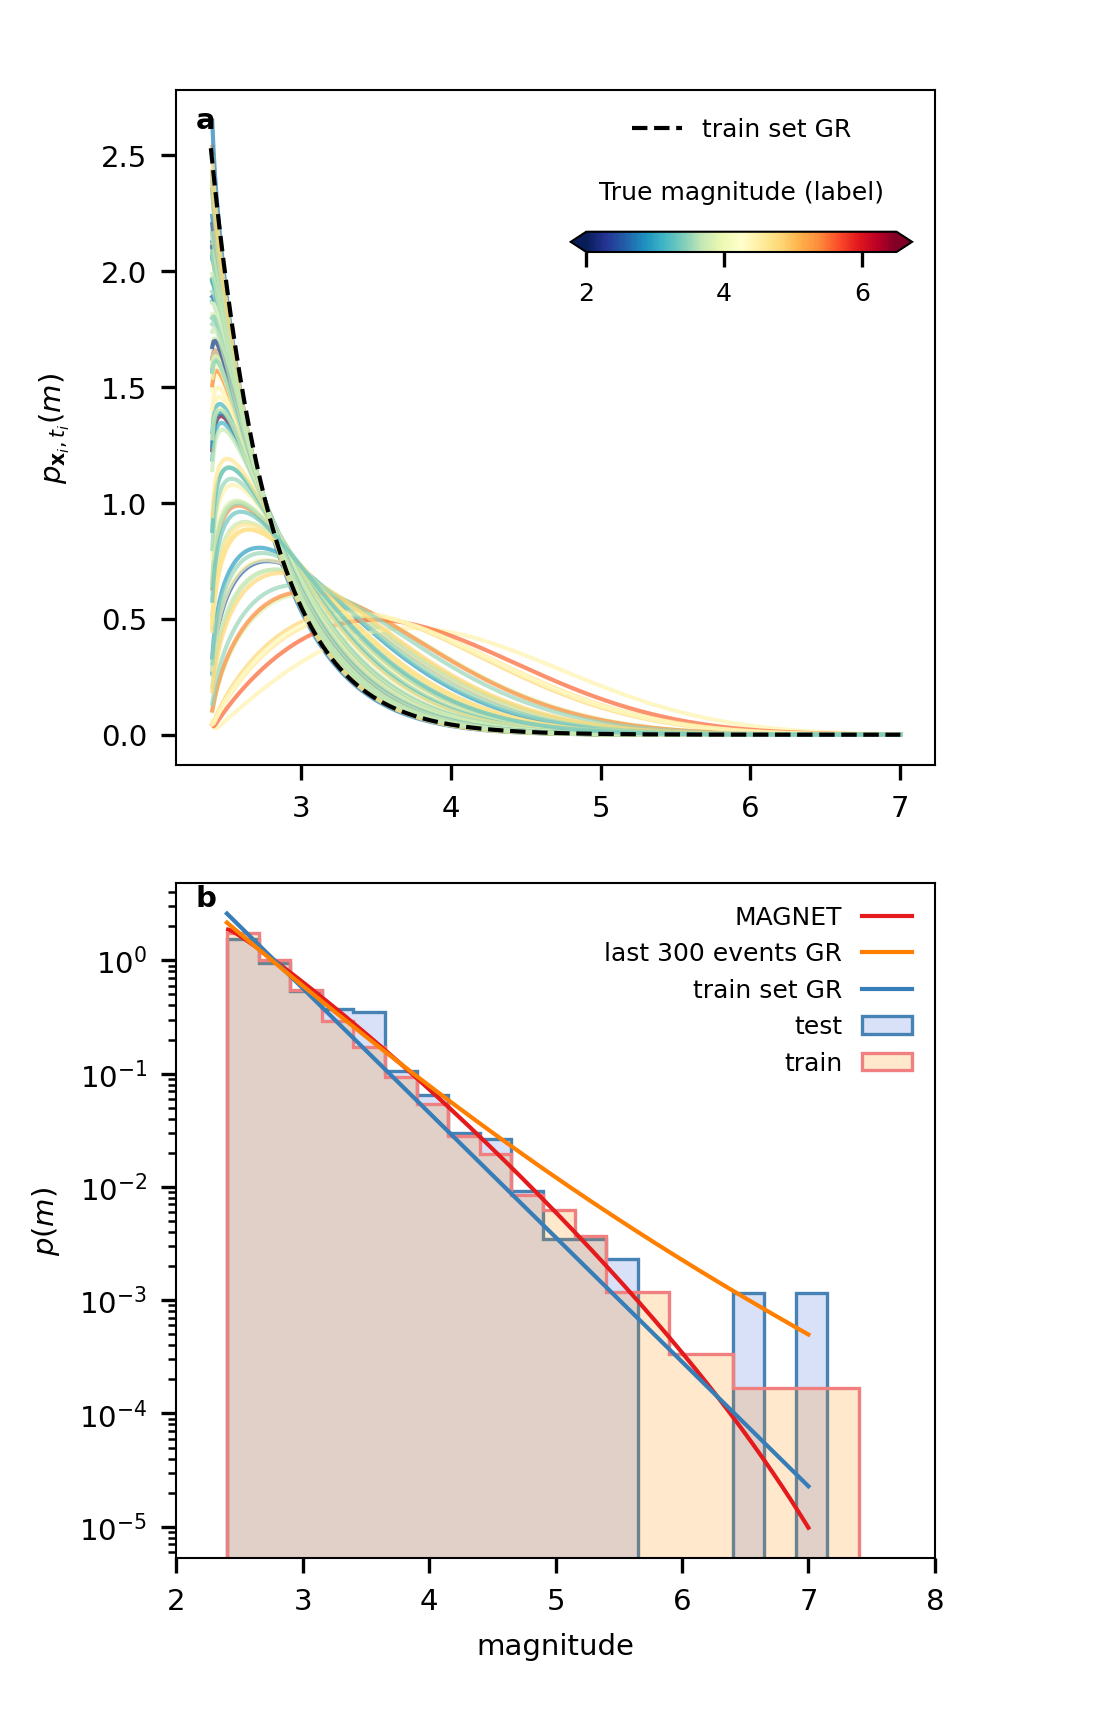

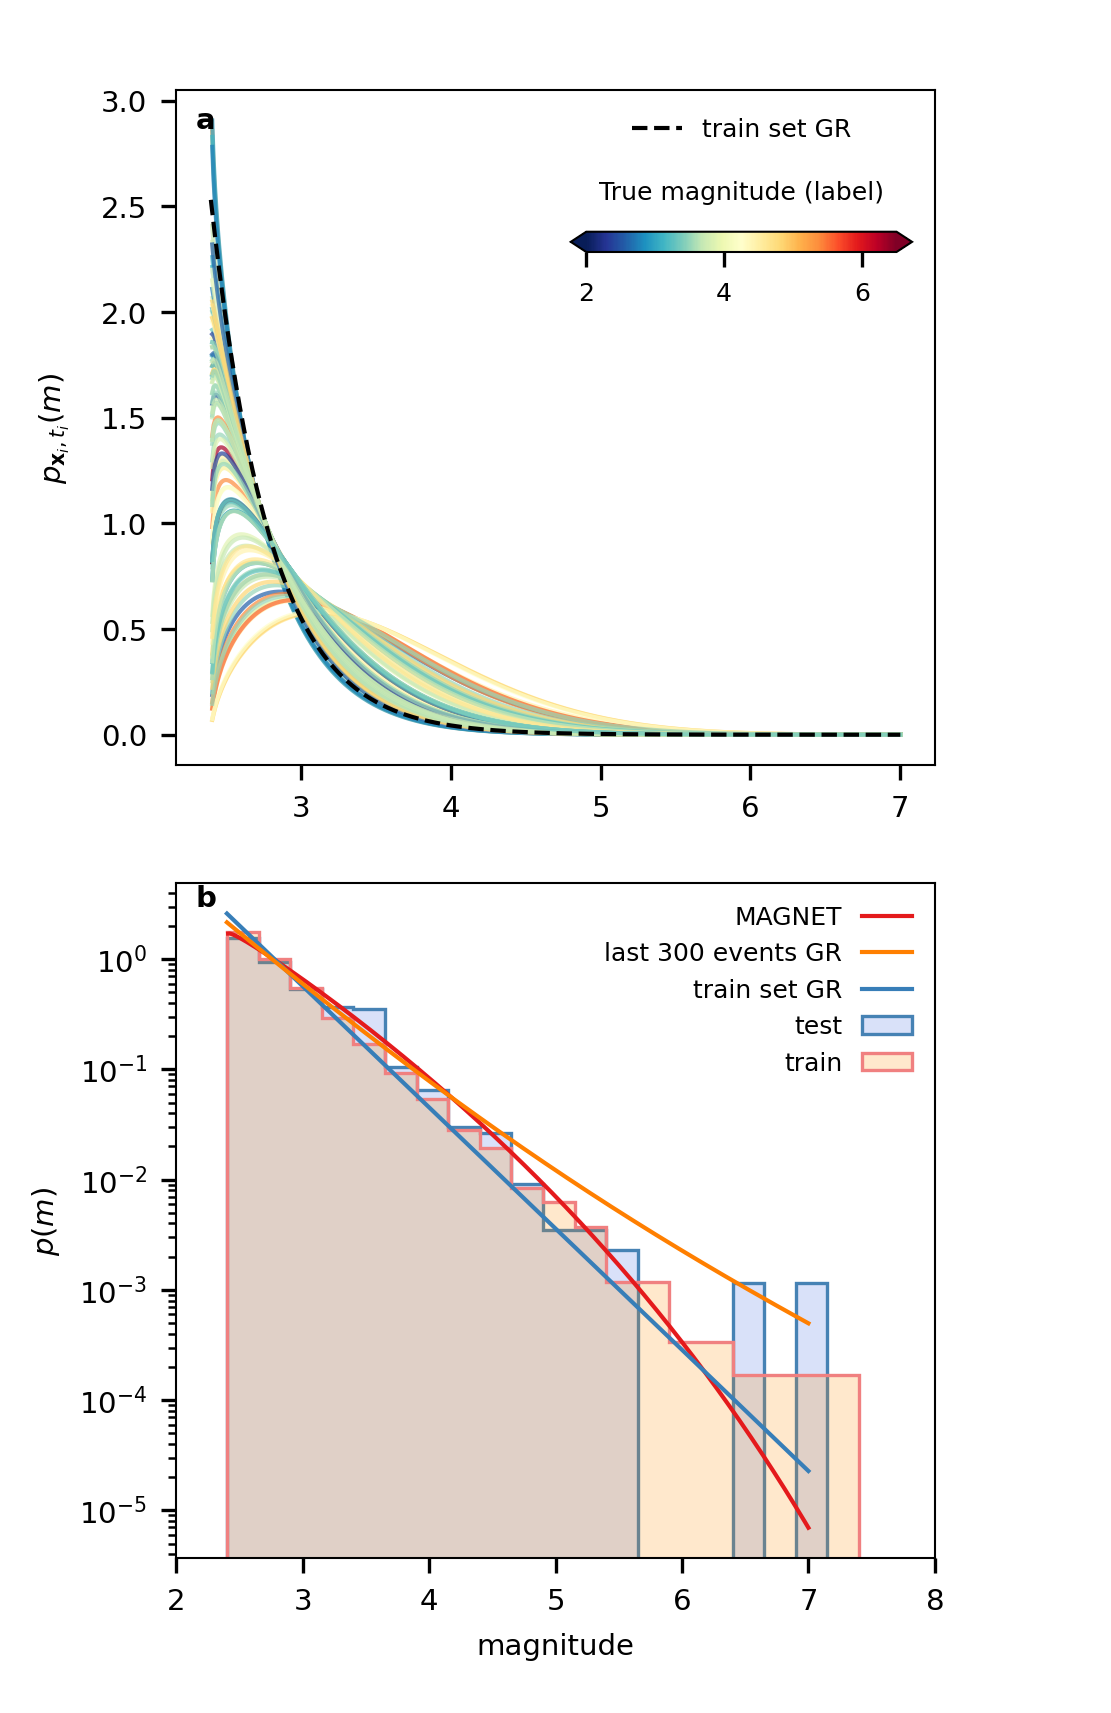

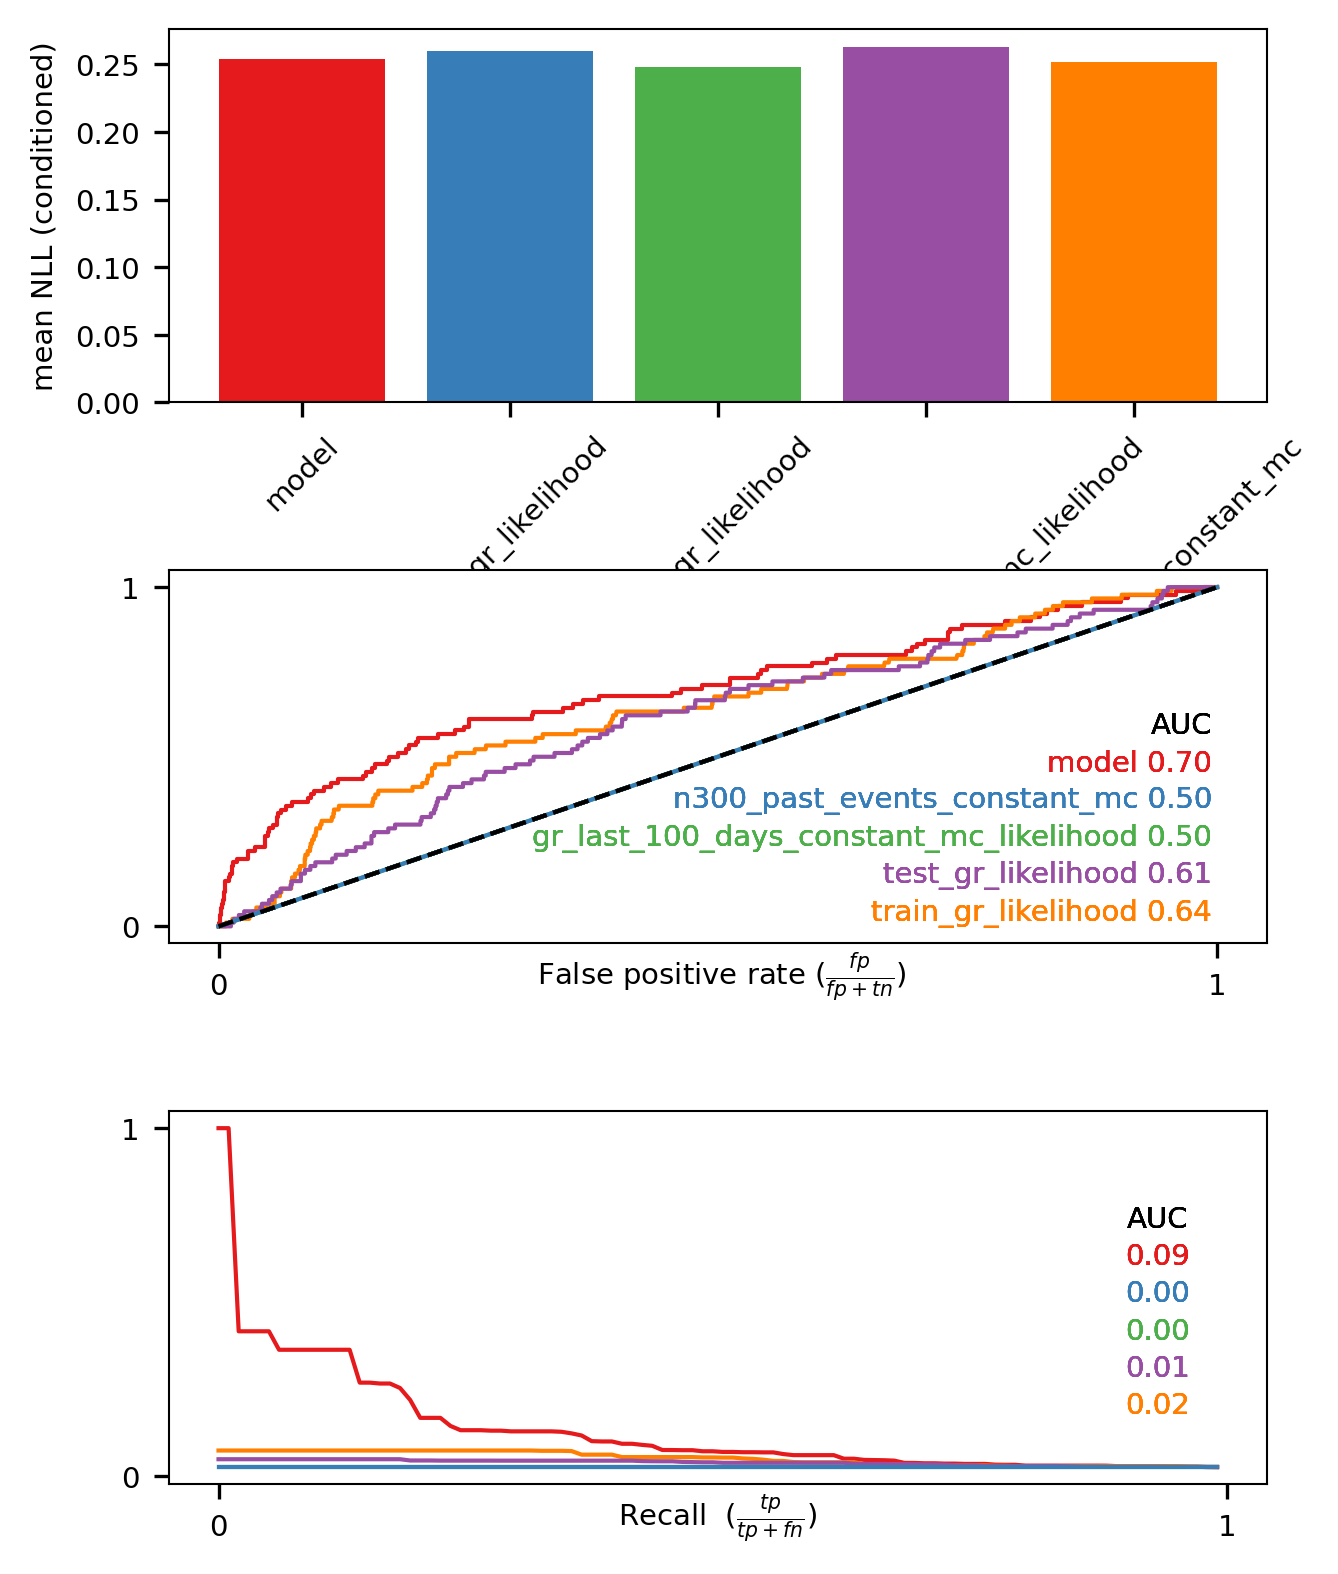

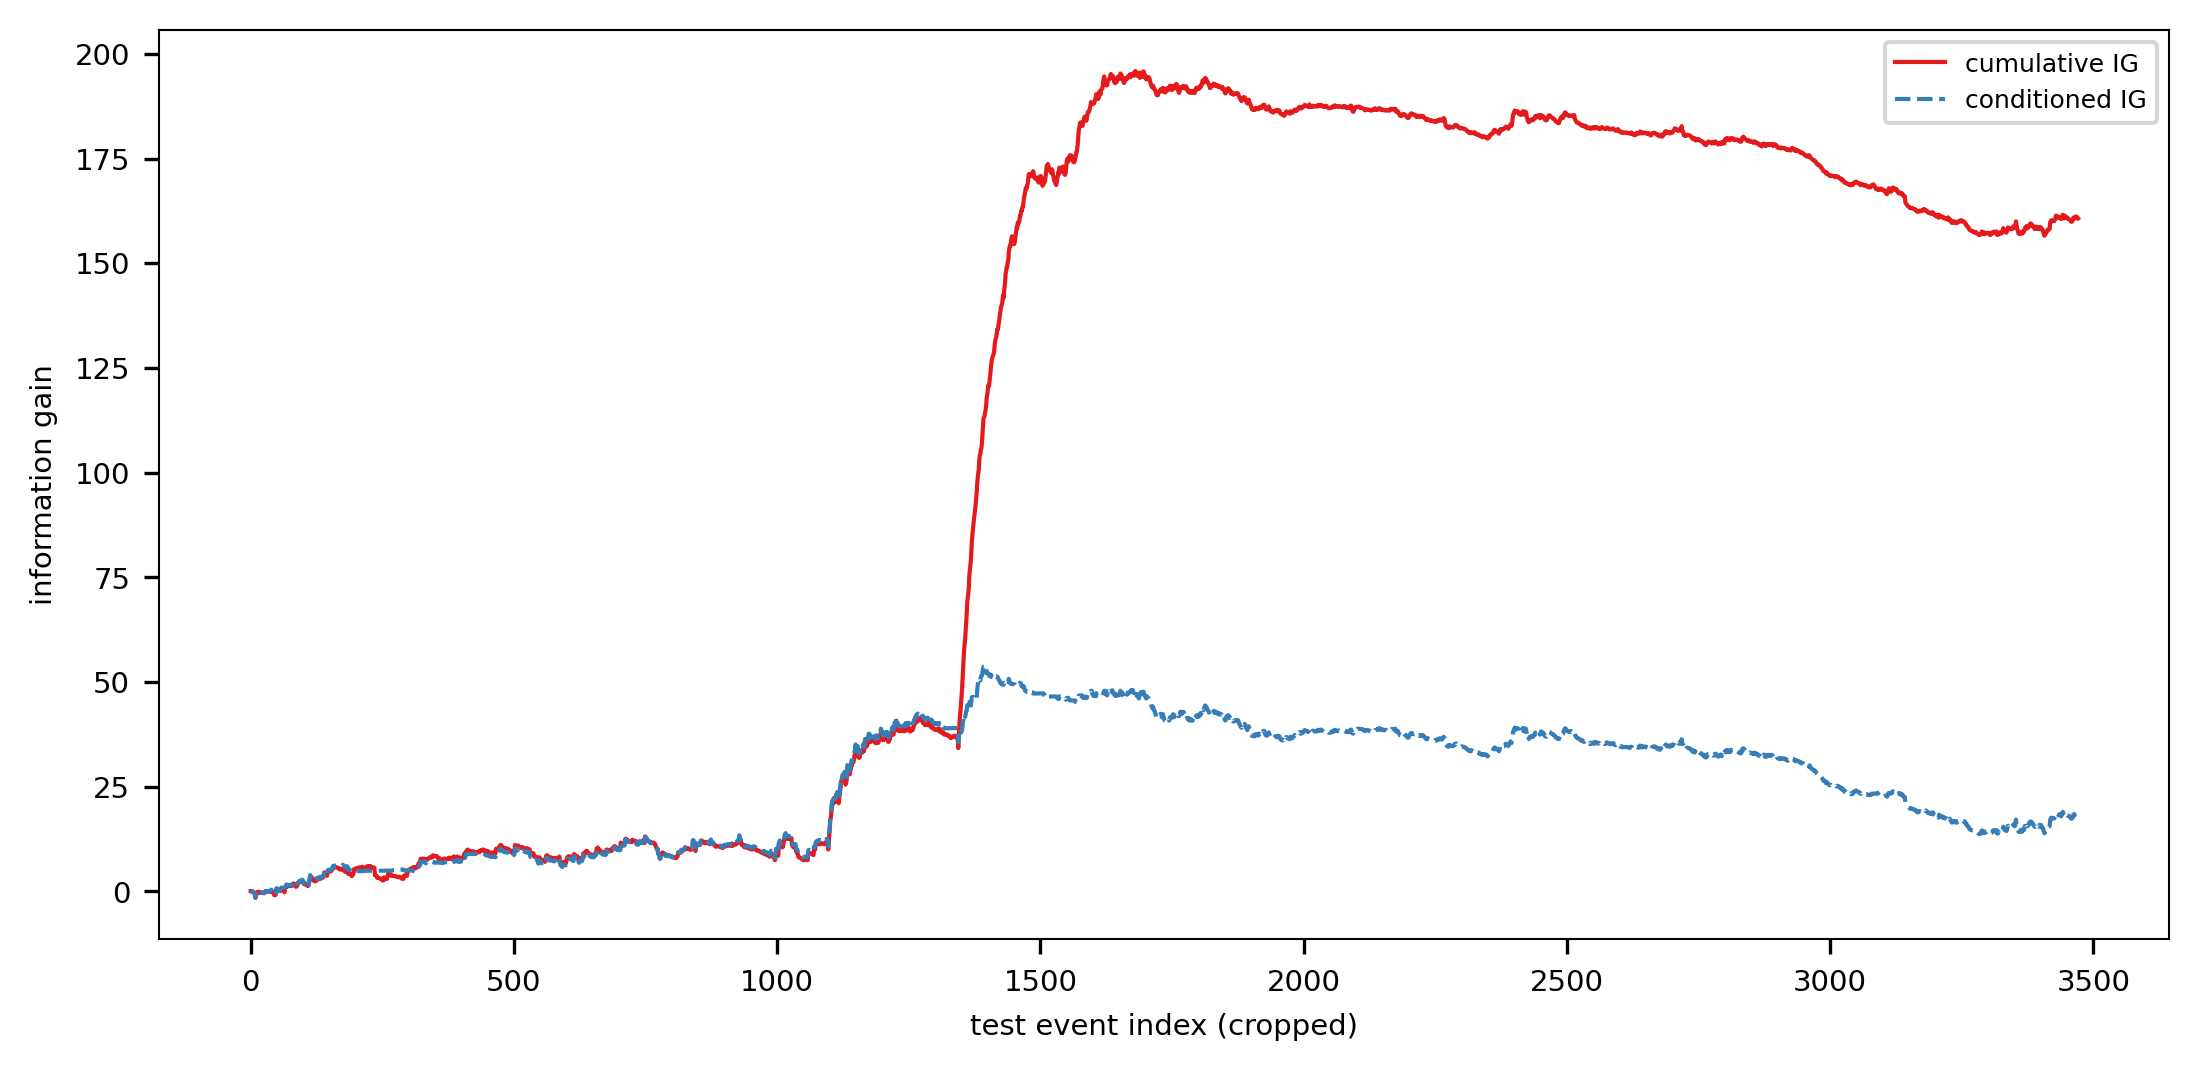

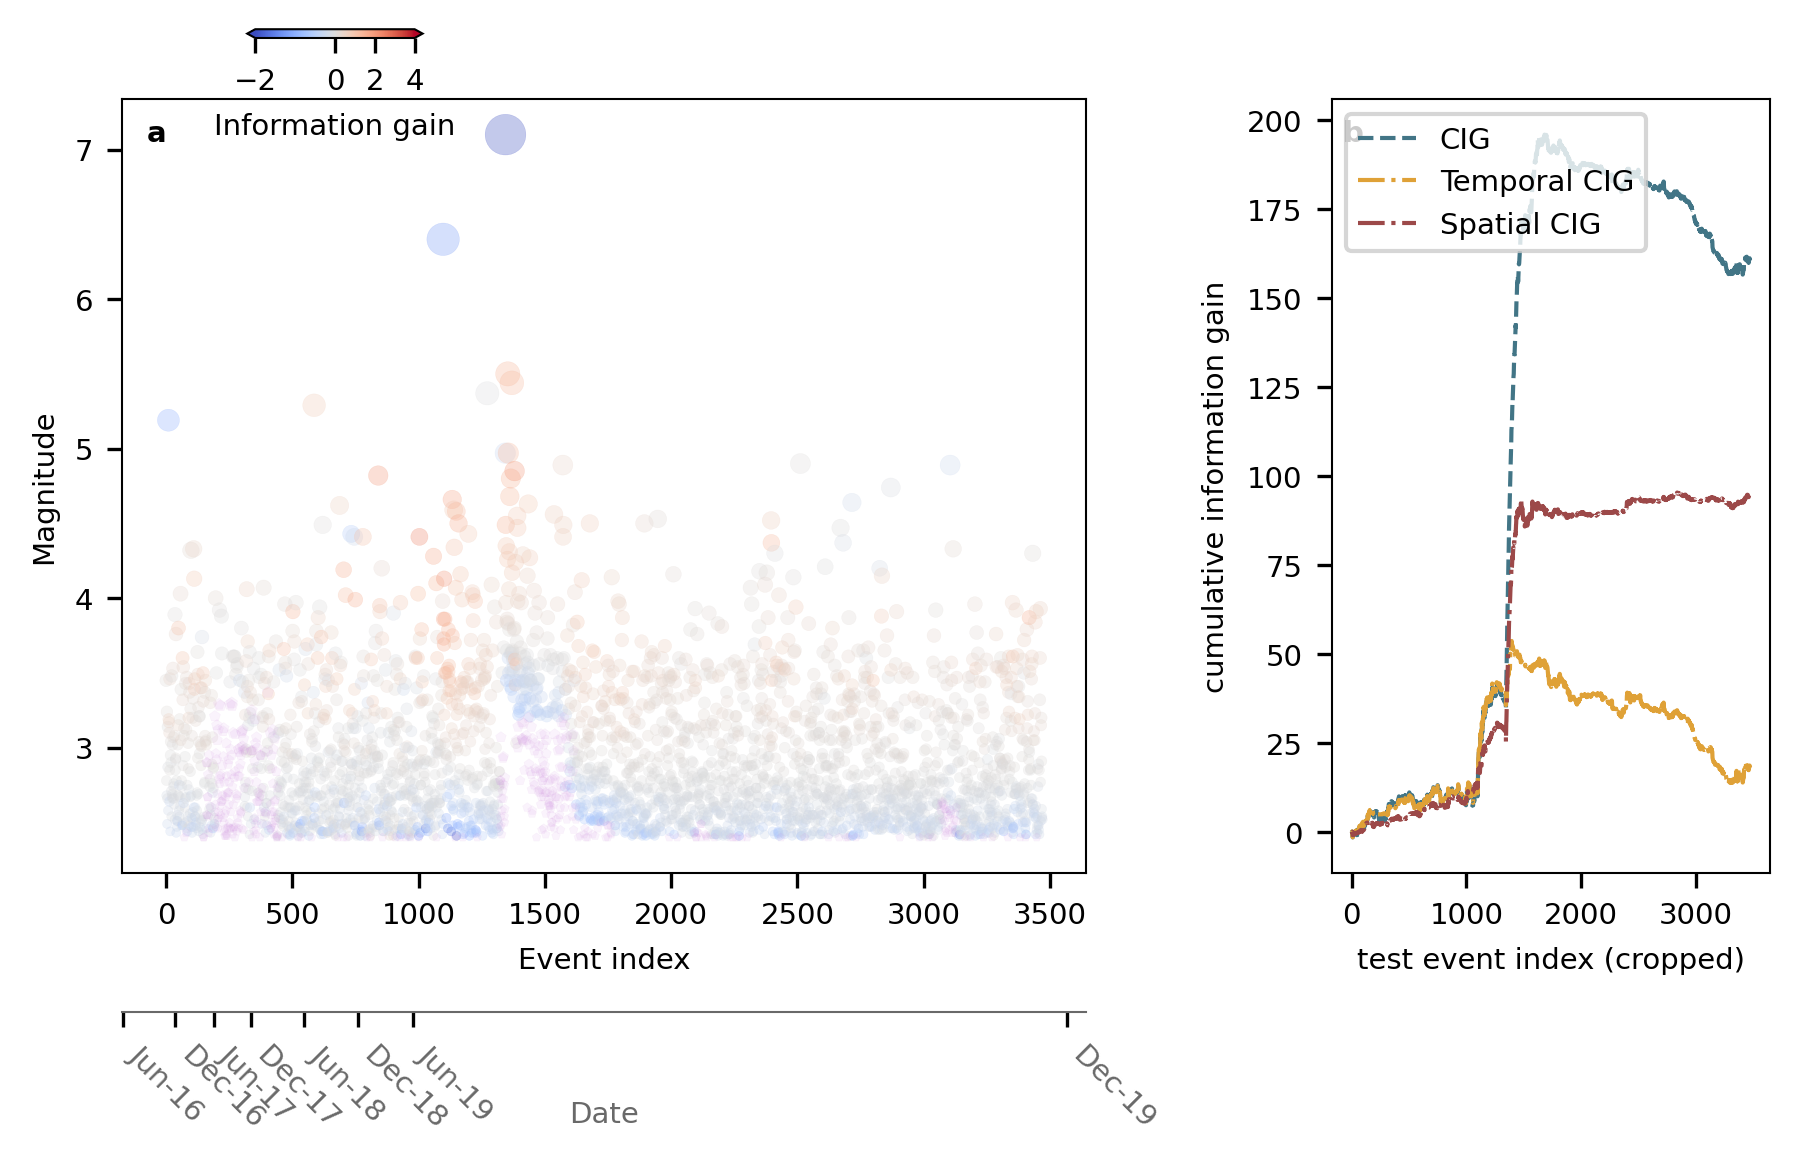

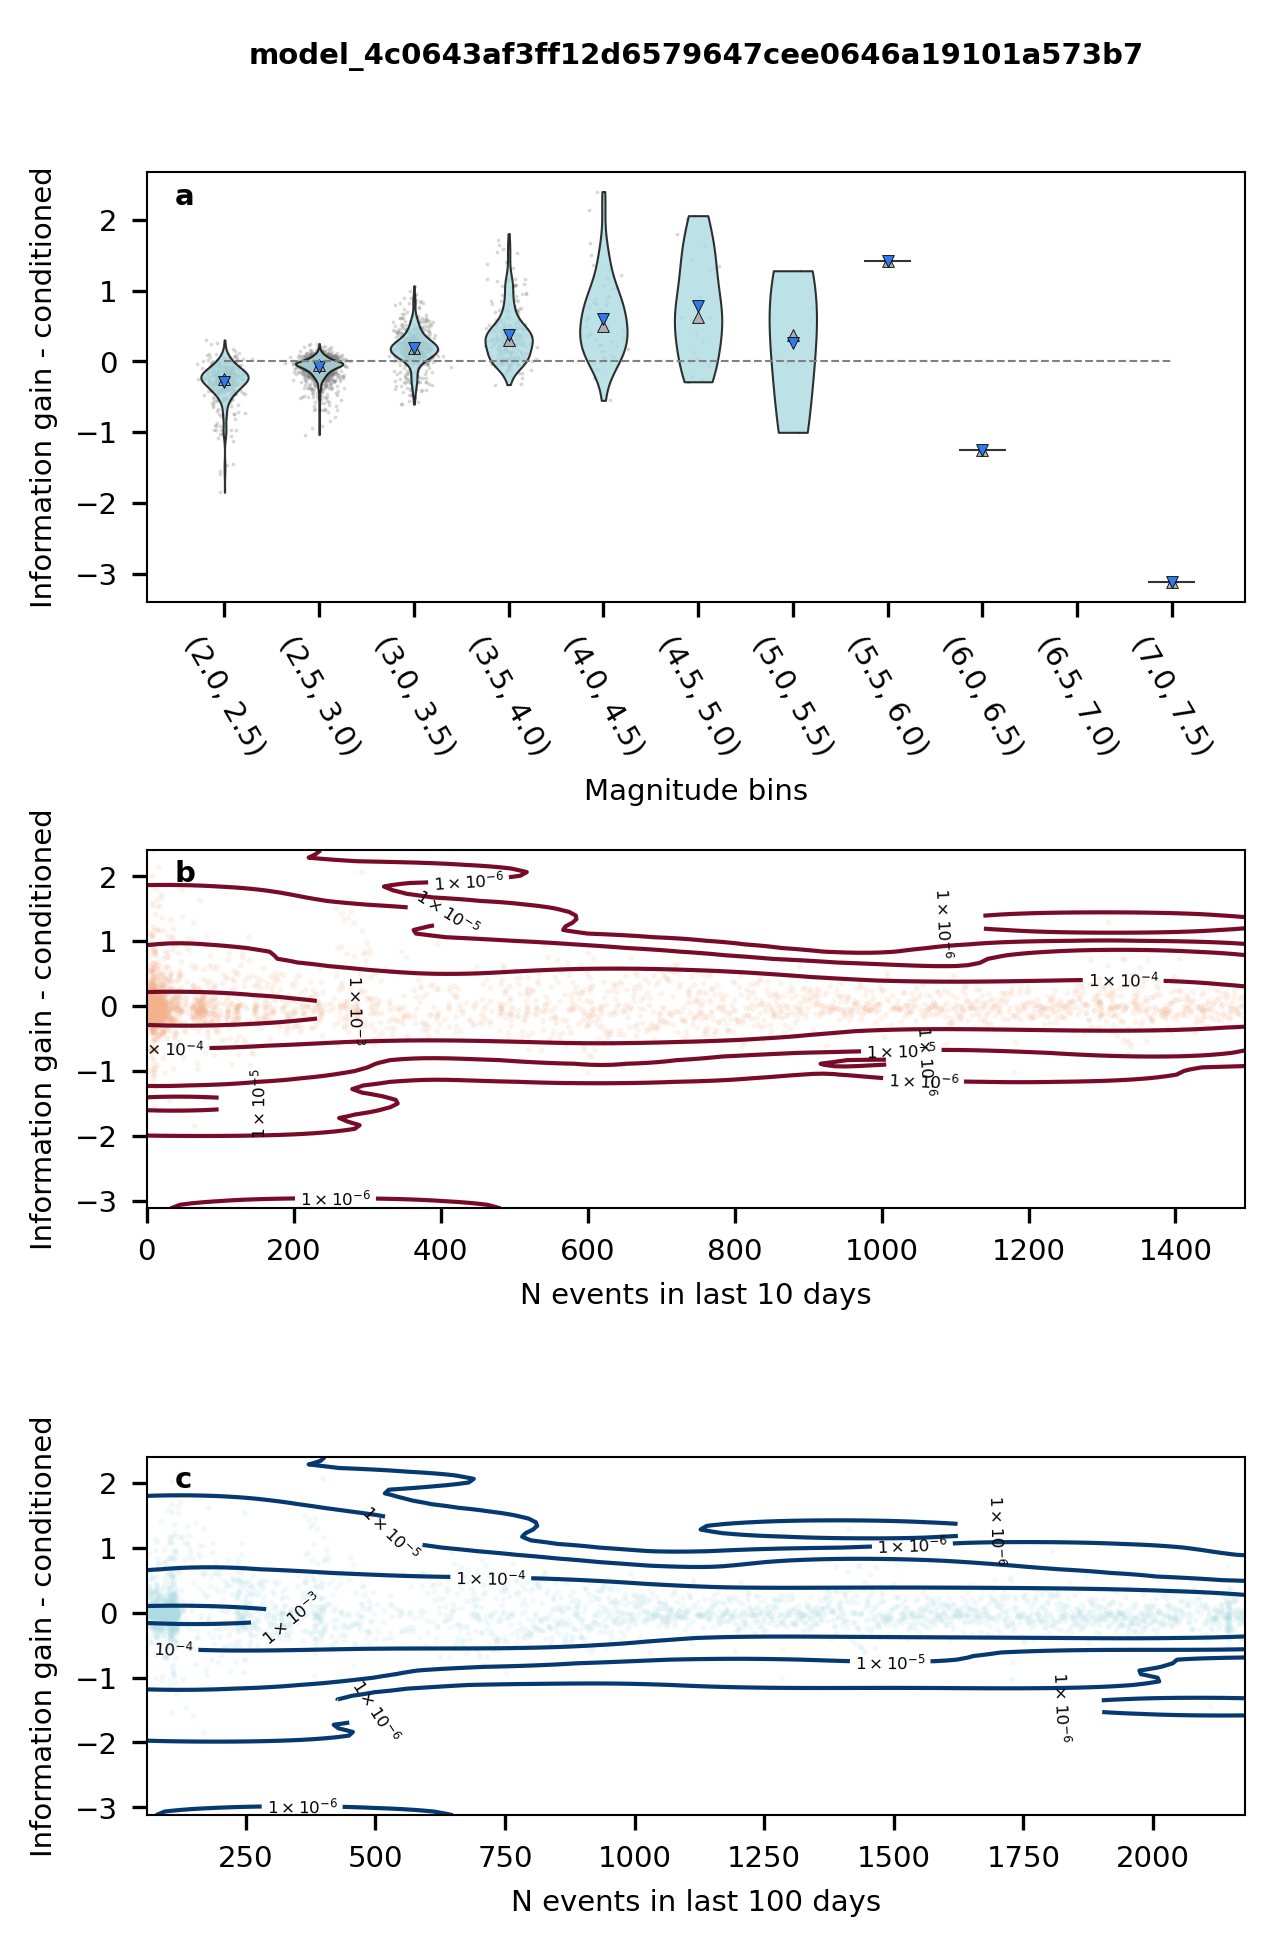

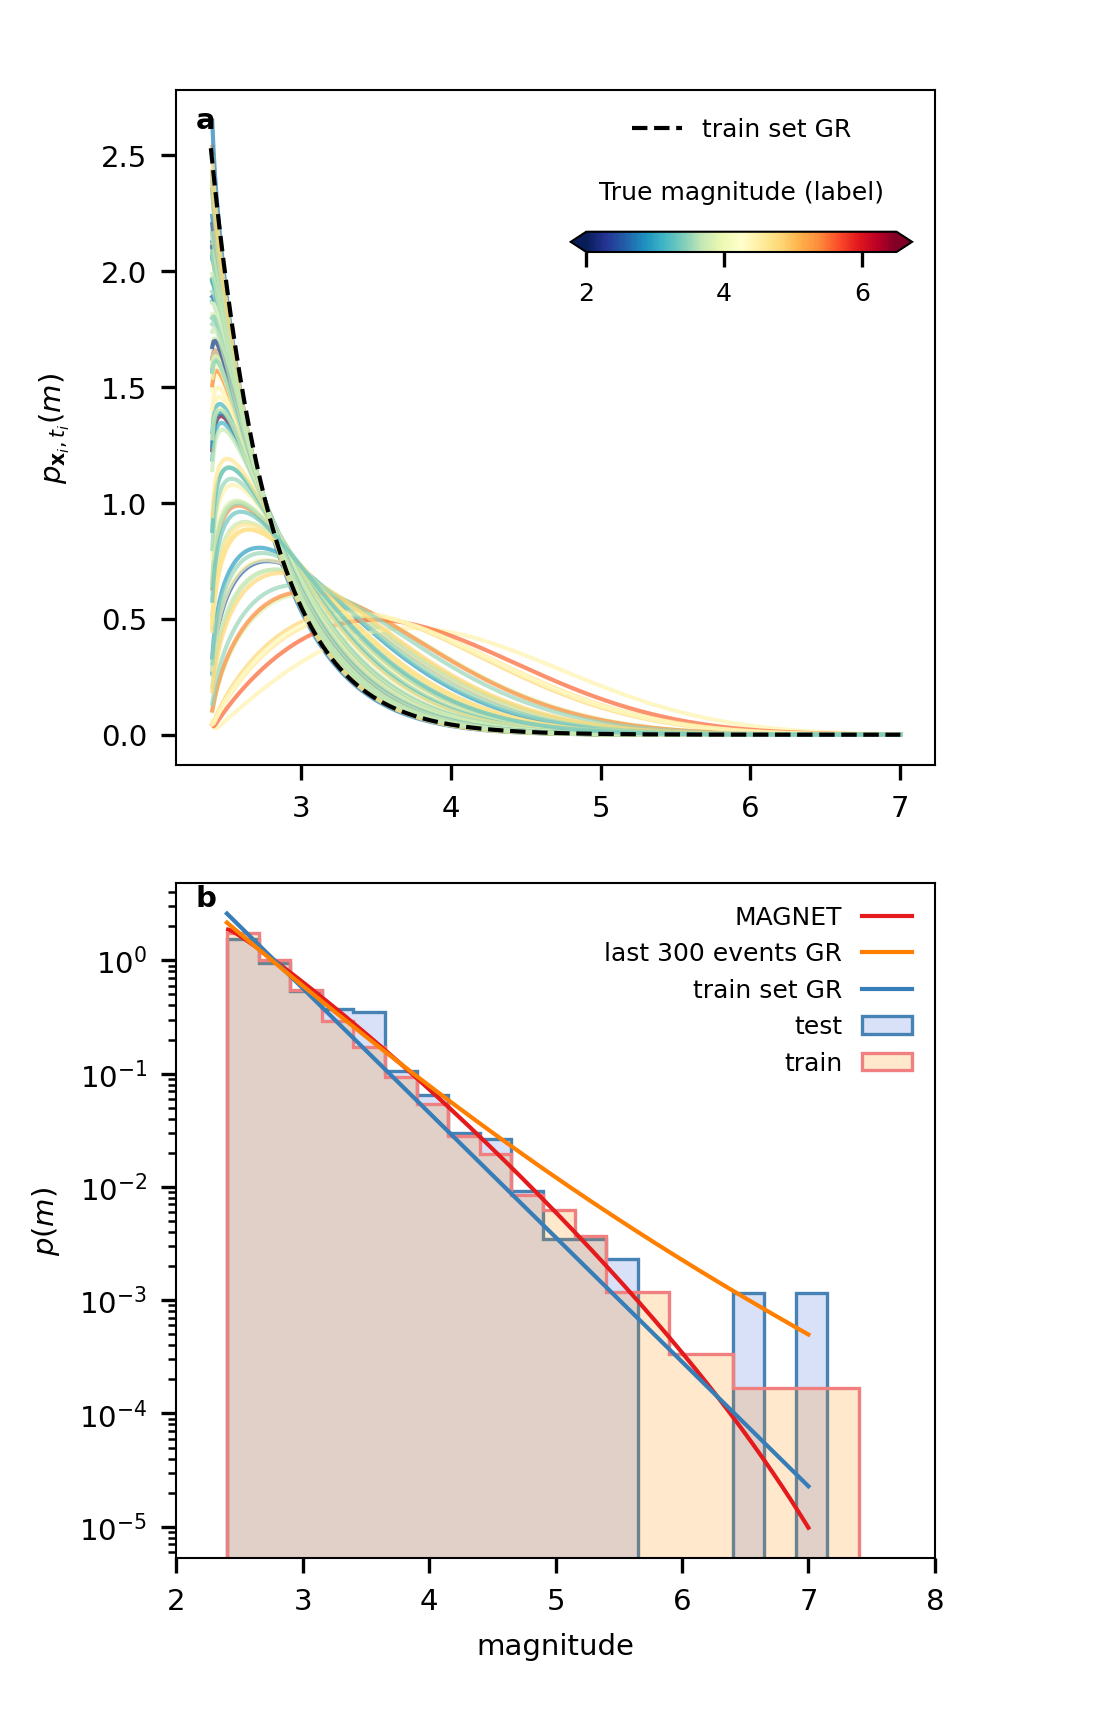

In [24]:

main_fig = plt.figure(figsize=(SCALE*89/INCHES_TO_MM, SCALE*140/INCHES_TO_MM), dpi=300)
gs = GridSpec(5, 3, width_ratios=[0.05, 1, 0.05], height_ratios=[0.005, 1, 0.005, 1, 0.1],
              left=0, right=1, top=1, bottom=0, wspace=0.39, hspace=0.2)
gs.tight_layout(figure=main_fig, pad=10)
main_fig.add_subplot(gs[:, :]).axis('off')
ax_pdfs = main_fig.add_subplot(gs[1, 1])
ax_marginal = main_fig.add_subplot(gs[3, 1])
colorbar_dim = [0.45, 0.03, 0.52, 0.76]  # width, height, left, bottom
legend_bbox = (colorbar_dim[2] + colorbar_dim[0] / 2, colorbar_dim[3] + colorbar_dim[1] + 0.1)
fill_axes_w_color_pdfs(
    DATA_NAME, ax_pdfs, colorbar_dim=colorbar_dim, labelpad=-30, ylabel_pad=7,
    legend_bbox=legend_bbox)
fill_axes_w_marginal_pdf(DATA_NAME, ax_marginal, xlim=(2, 8))
plot_letter(ax_pdfs, 'a'); plot_letter(ax_marginal, 'b')
display(main_fig)
if DO_SAVE: save_figure(main_fig, 'raw_data_main_text')


## Figure 2 — `metrics_conditioned`

model_benchmark: model_test
model_benchmark: n300_past_events_constant_mc_b_stability_test
model_benchmark: gr_last_100_days_constant_mc_likelihood_test
model_benchmark: test_gr_likelihood_test
model_benchmark: train_gr_likelihood_test
model_benchmark: model_test
model_benchmark: n300_past_events_constant_mc_b_stability_test
model_benchmark: gr_last_100_days_constant_mc_likelihood_test
model_benchmark: test_gr_likelihood_test
model_benchmark: train_gr_likelihood_test


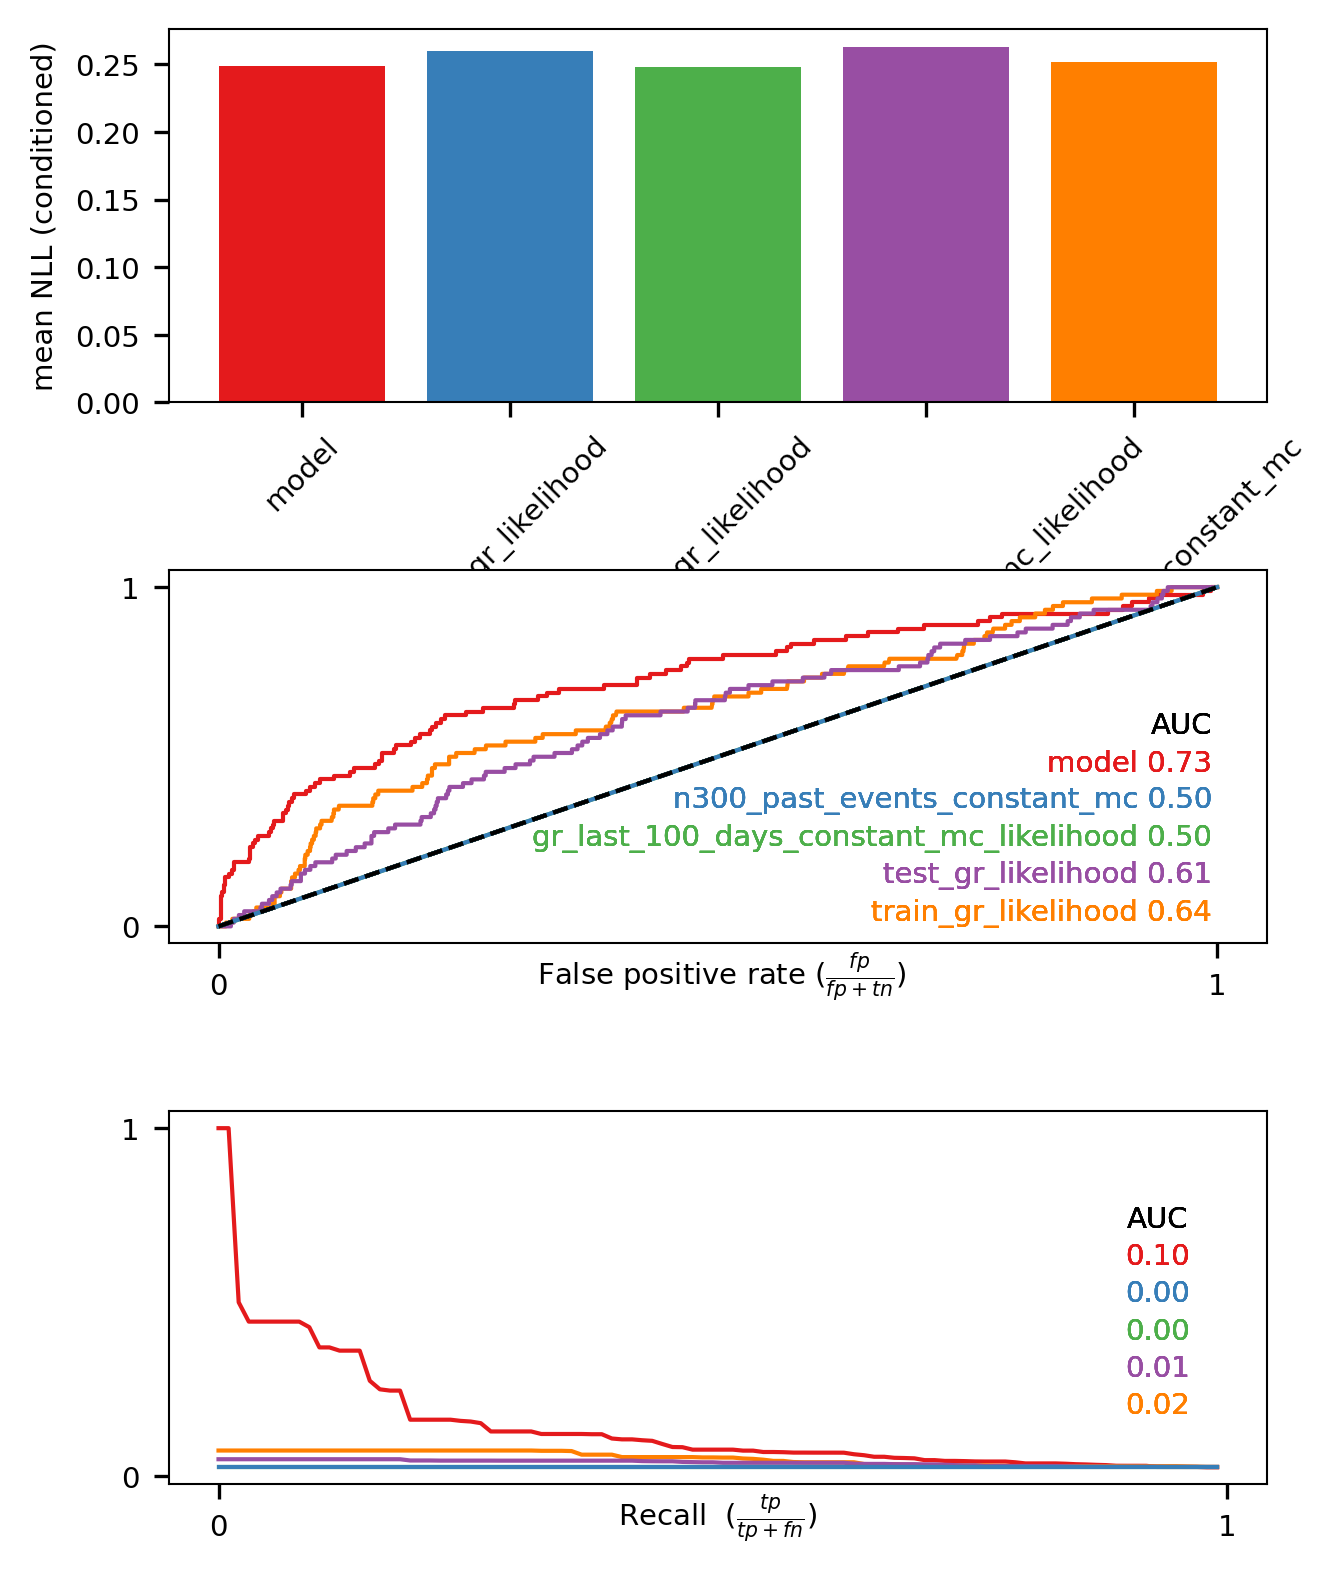

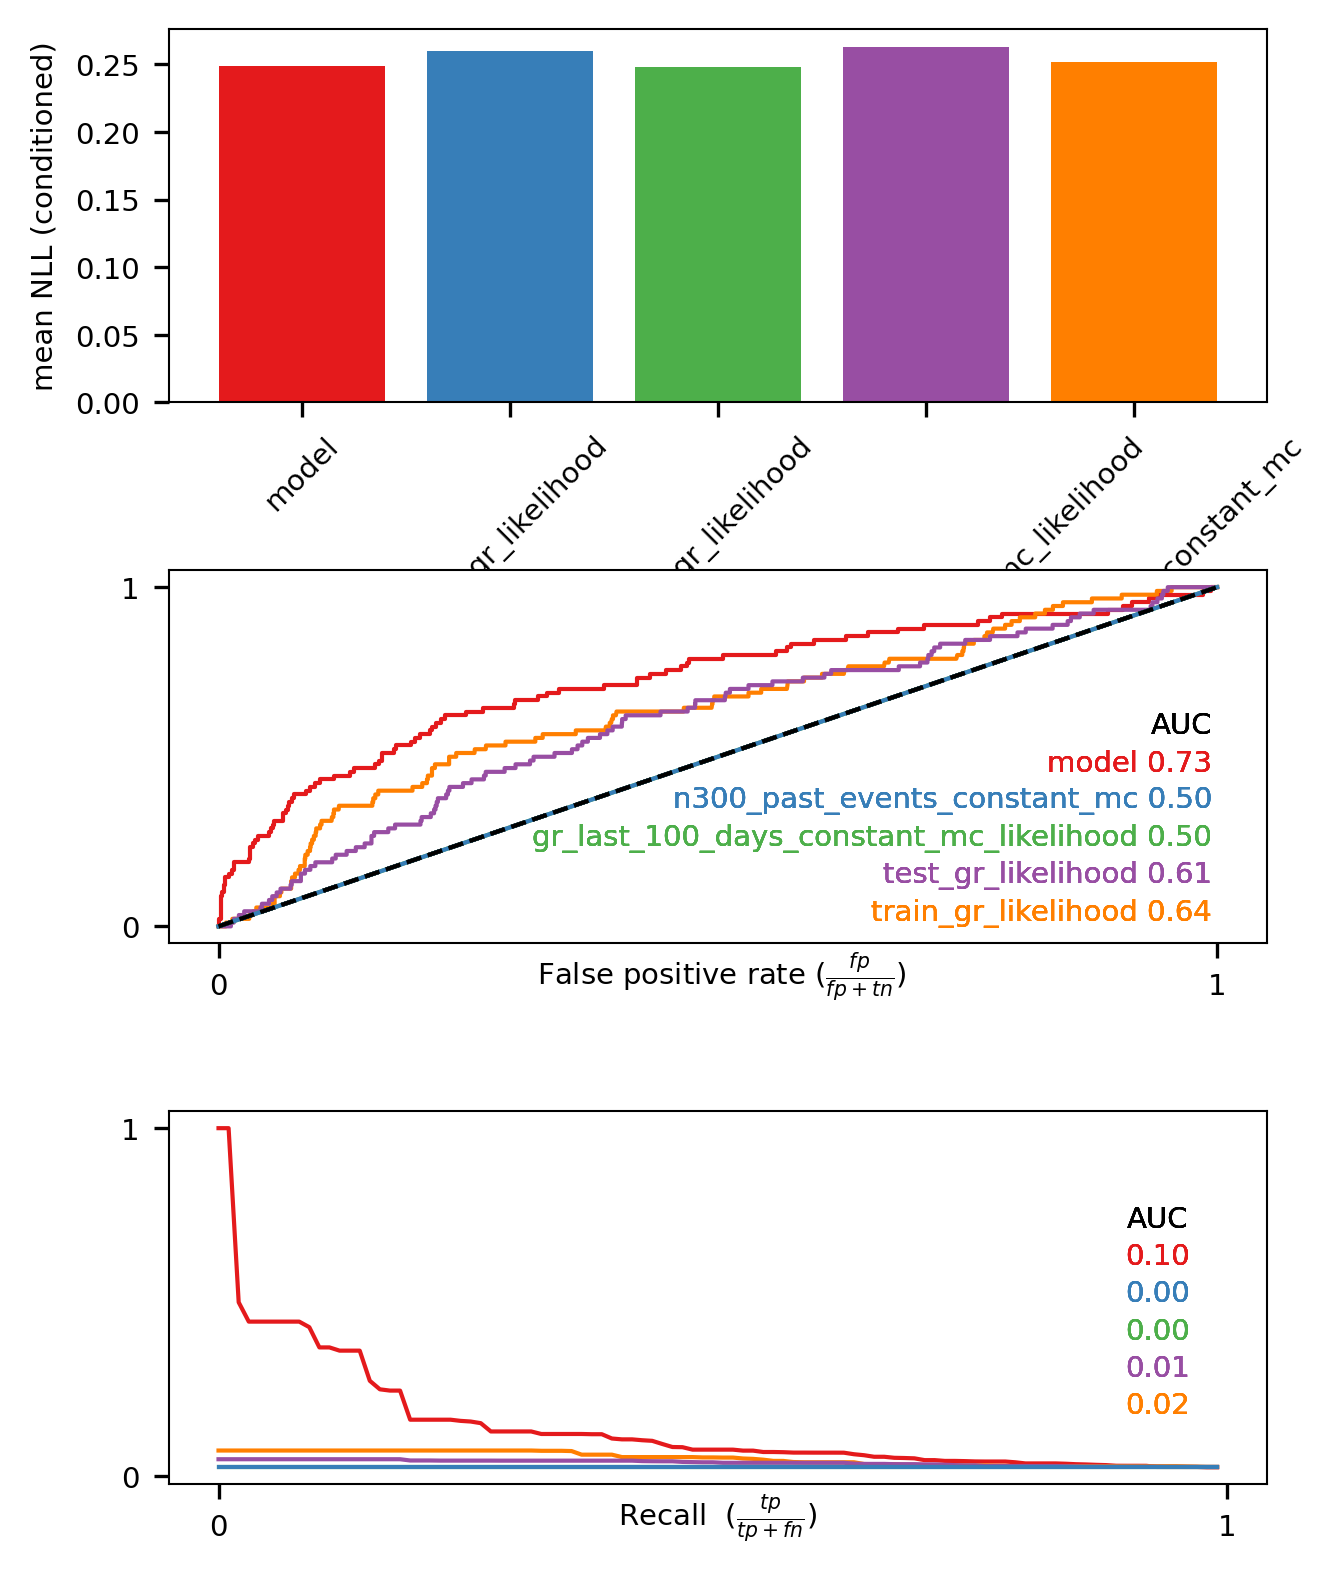

In [25]:
metrics_fig = plt.figure(figsize=(SCALE*120/INCHES_TO_MM, SCALE*160/INCHES_TO_MM), dpi=300)
gs = GridSpec(3, 1, height_ratios=[1, 1, 1], hspace=0.45)
ax_bar = metrics_fig.add_subplot(gs[0])
ax_roc = metrics_fig.add_subplot(gs[1])
ax_pr = metrics_fig.add_subplot(gs[2])

vals = summary_cond[SET_TO_PLOT].loc[MODELS_TO_PLOT].astype(float)
are_infs = np.isinf(vals)
if are_infs.any():
    vals = vals.copy()
    vals[are_infs] = vals[~are_infs].max() * 1.2
ax_bar.bar(MODELS_TO_PLOT, vals, color=[COLOR_PER_MODEL[m] for m in MODELS_TO_PLOT])
ax_bar.set_ylabel('mean NLL (conditioned)')
ax_bar.tick_params(axis='x', rotation=45)

# boolean_metrics_dict is computed during analysis (or loaded from cache).
plot_ROC(
    boolean_metrics_dict,
    MODELS_TO_PLOT,
    COLOR_PER_MODEL,
    ax_roc,
    MODELS_TO_PLOT,
    m_thresh=4,
    set_name=SET_TO_PLOT,
    is_first=True,
)
plot_PR(boolean_metrics_dict, MODELS_TO_PLOT, COLOR_PER_MODEL, ax_pr, m_thresh=4, set_name=SET_TO_PLOT)
display(metrics_fig)
if DO_SAVE:
    save_figure(metrics_fig, 'metrics_conditioned')


## Figure 3 — `information_gain_over_time`

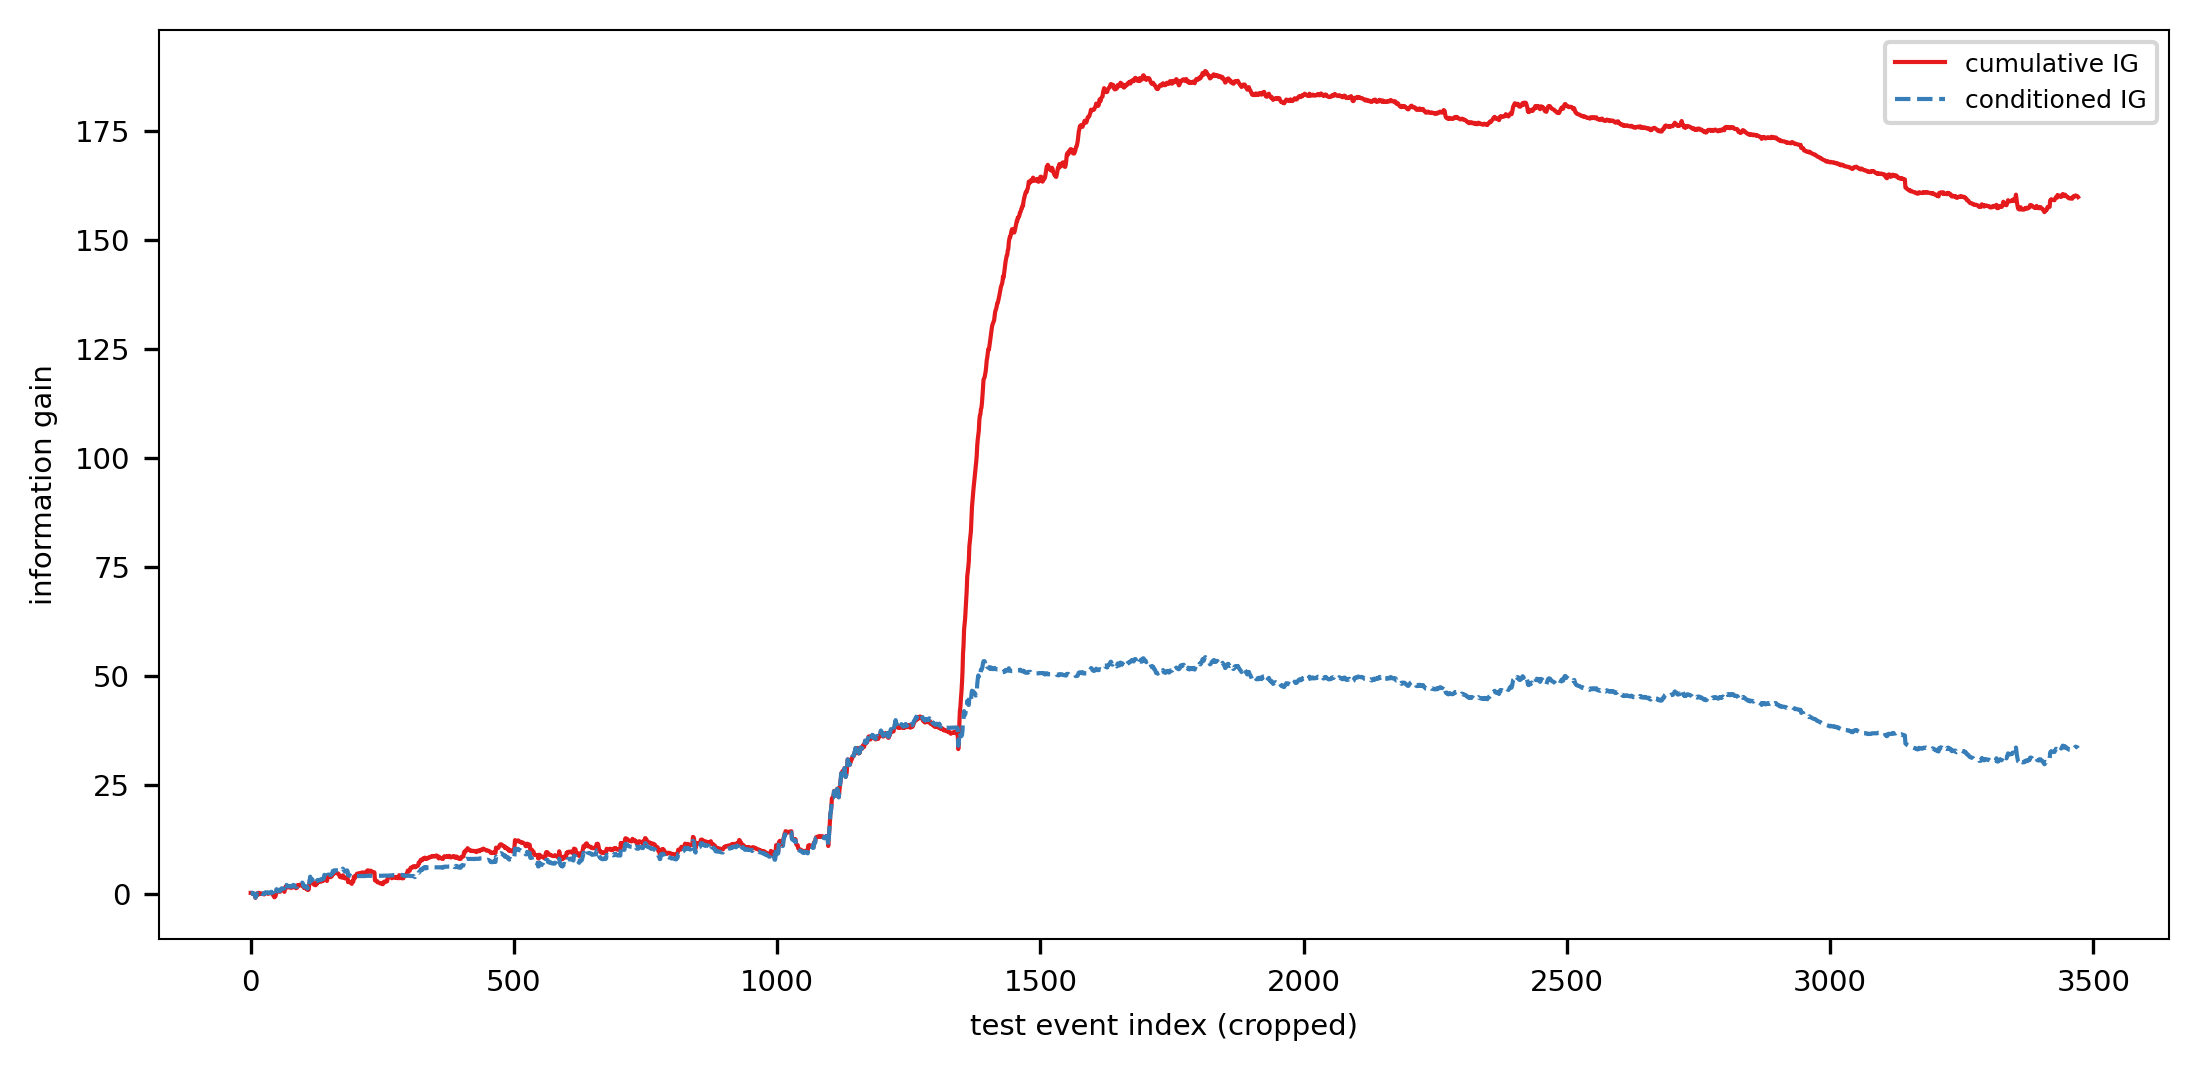

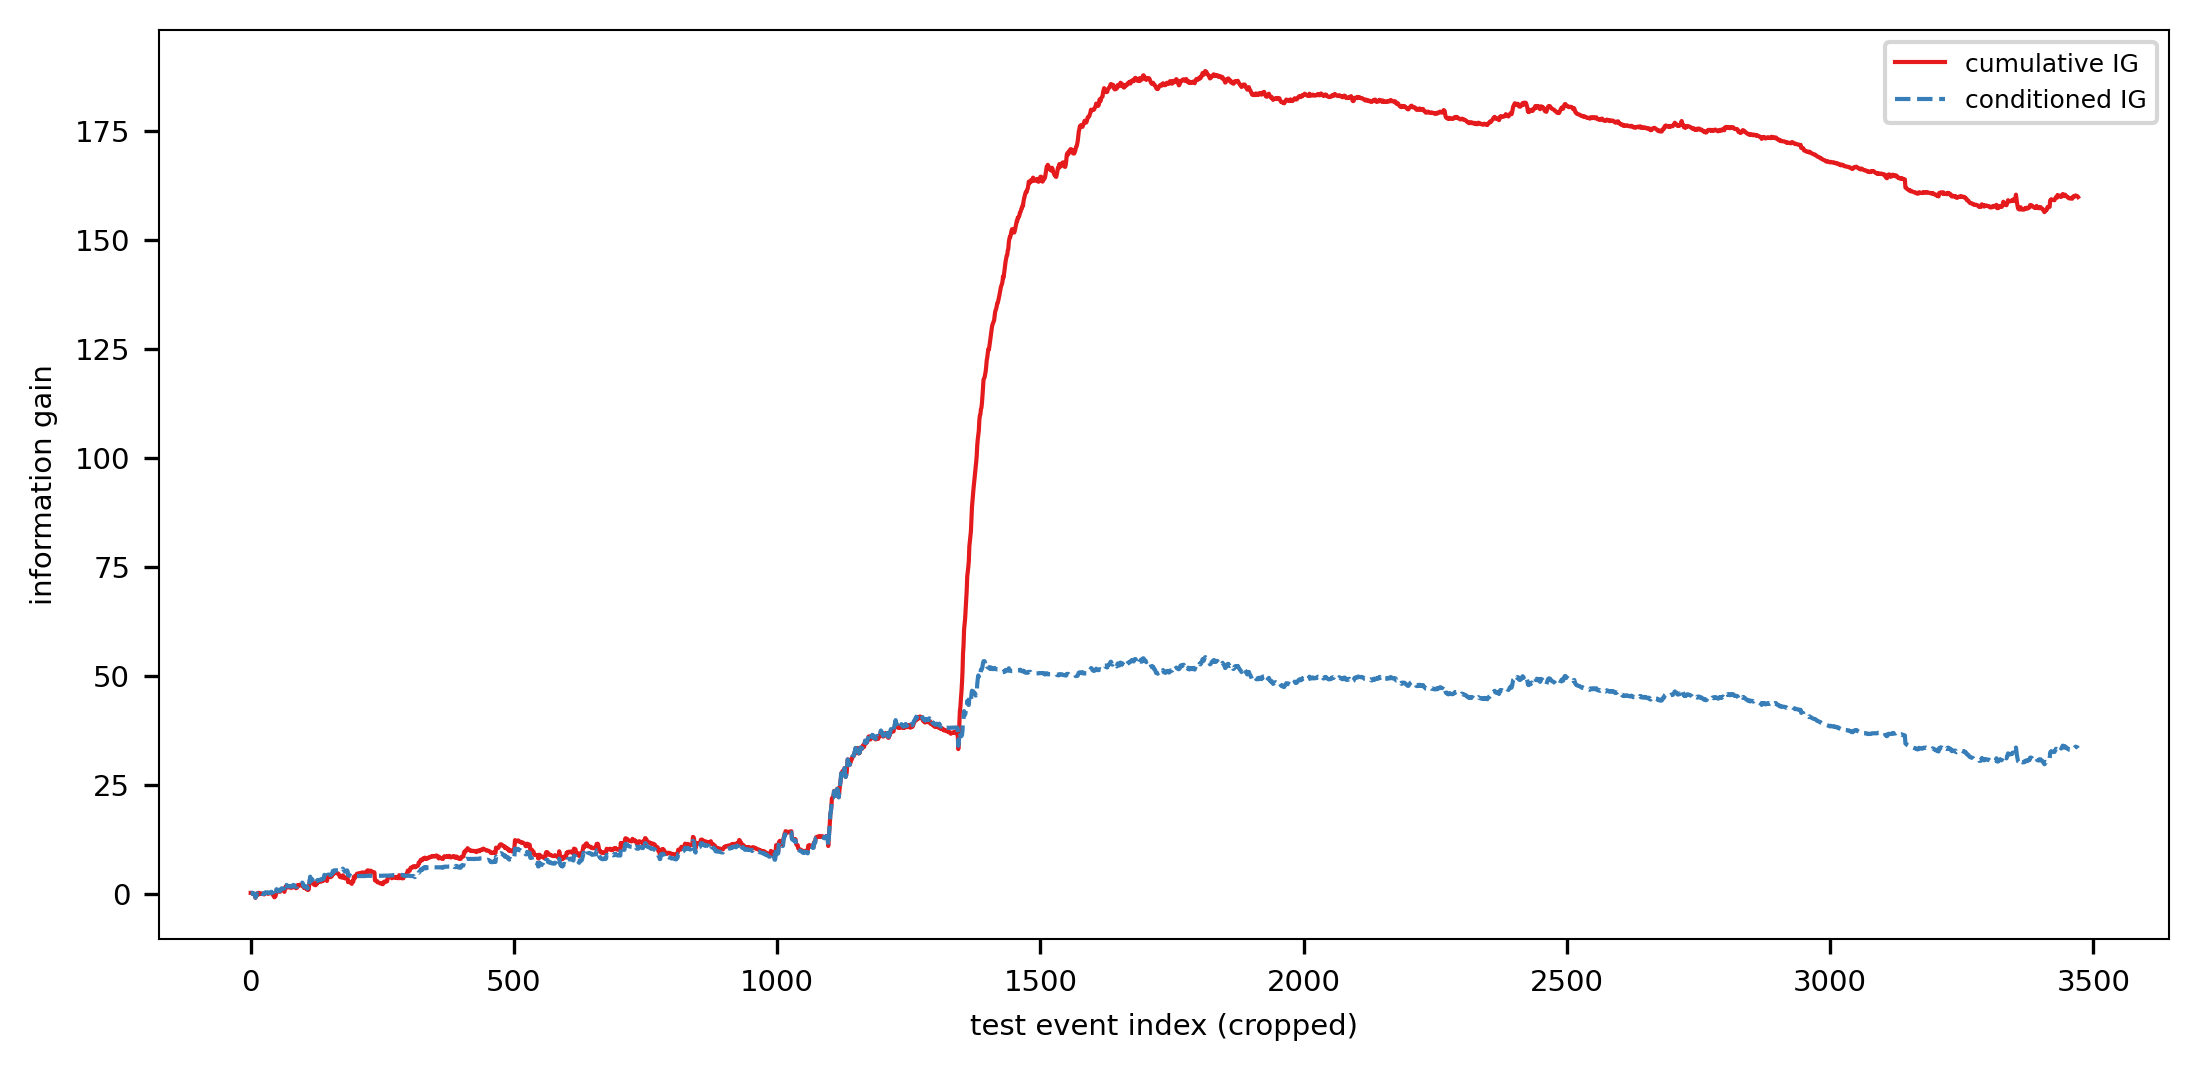

In [26]:
cropped = cropped_comparison_catalog
info_fig, ax = plt.subplots(figsize=(FIG_WIDTH * 1.2, FIG_HEIGHT))
ax.plot(cropped['information_gain'].values, label='cumulative IG')
ax.plot(cropped['information_gain_conditioned'].values, '--', label='conditioned IG')
ax.set_xlabel('test event index (cropped)')
ax.set_ylabel('information gain')
ax.legend()
display(info_fig)
if DO_SAVE:
    save_figure(info_fig, 'information_gain_over_time')


## Figure 4 — `cum_info_gain_conditioned_scatter`

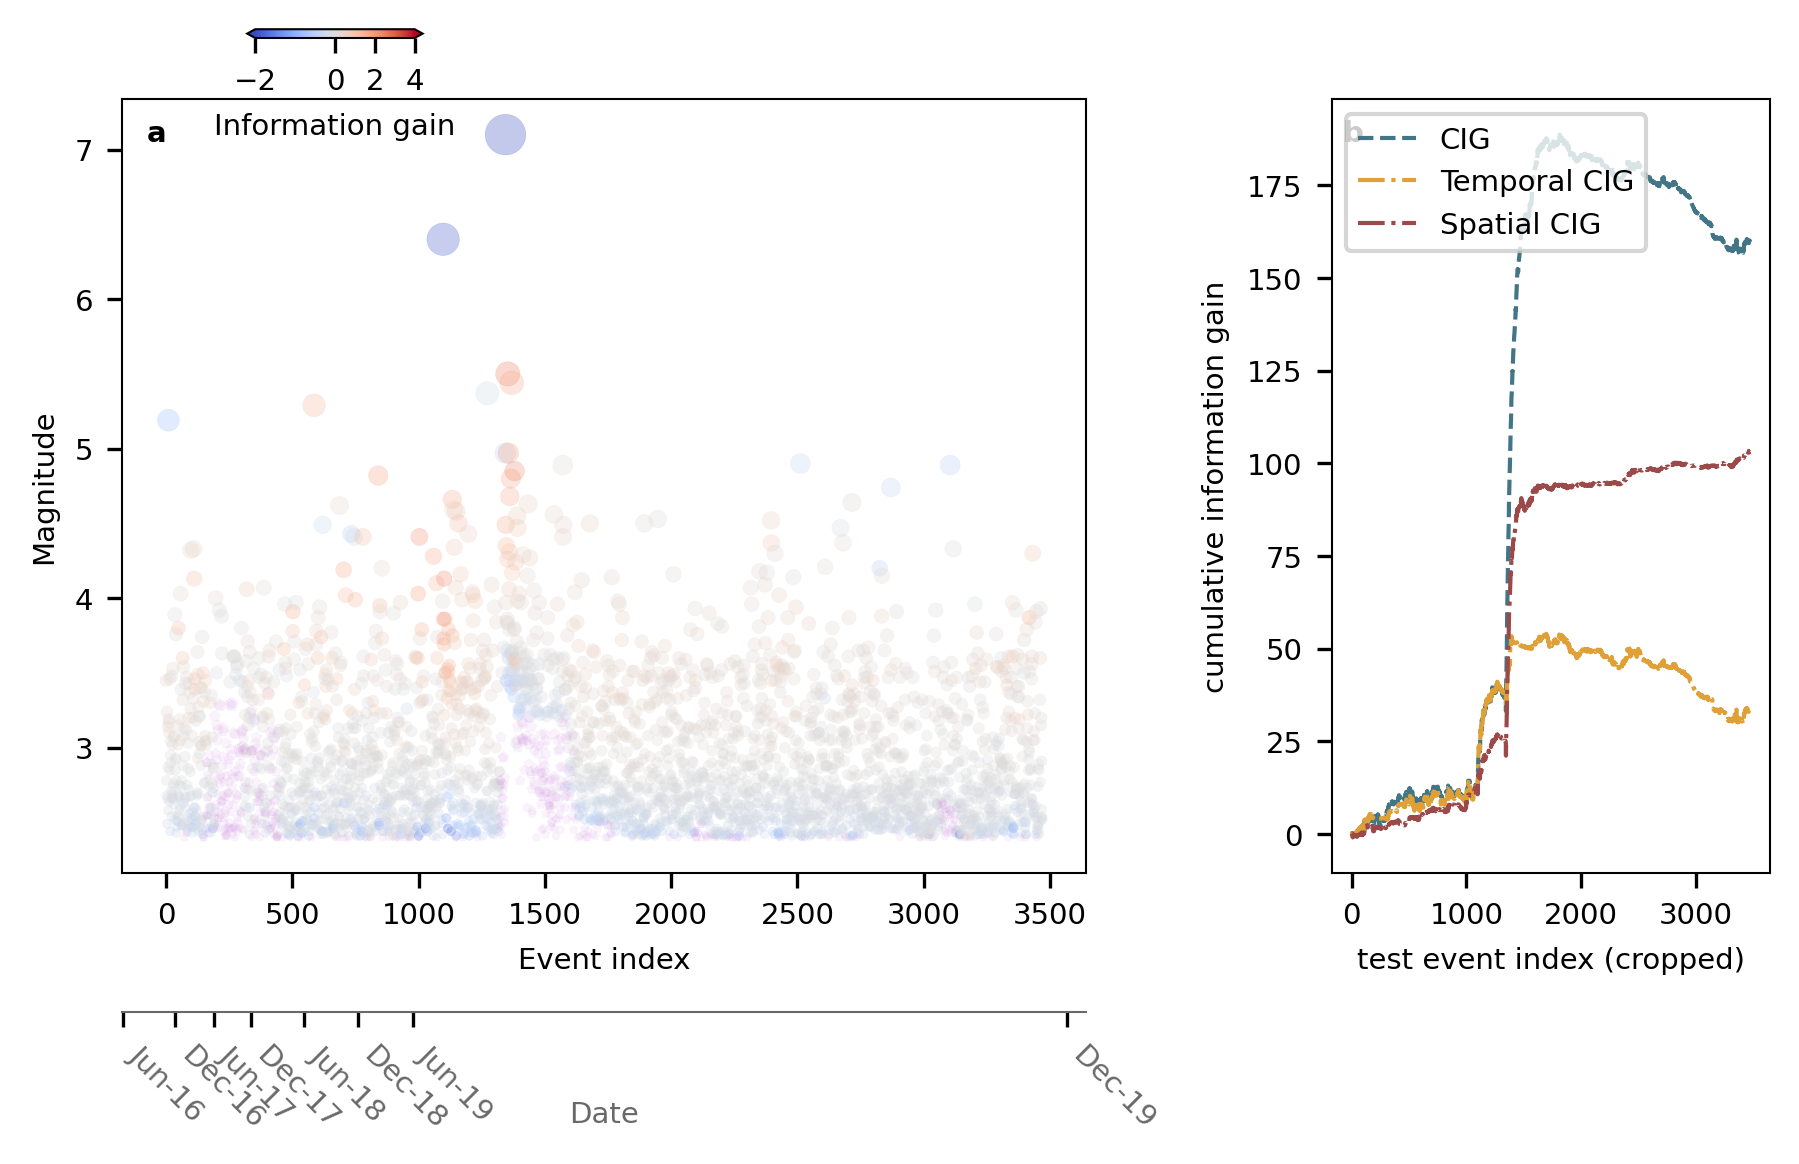

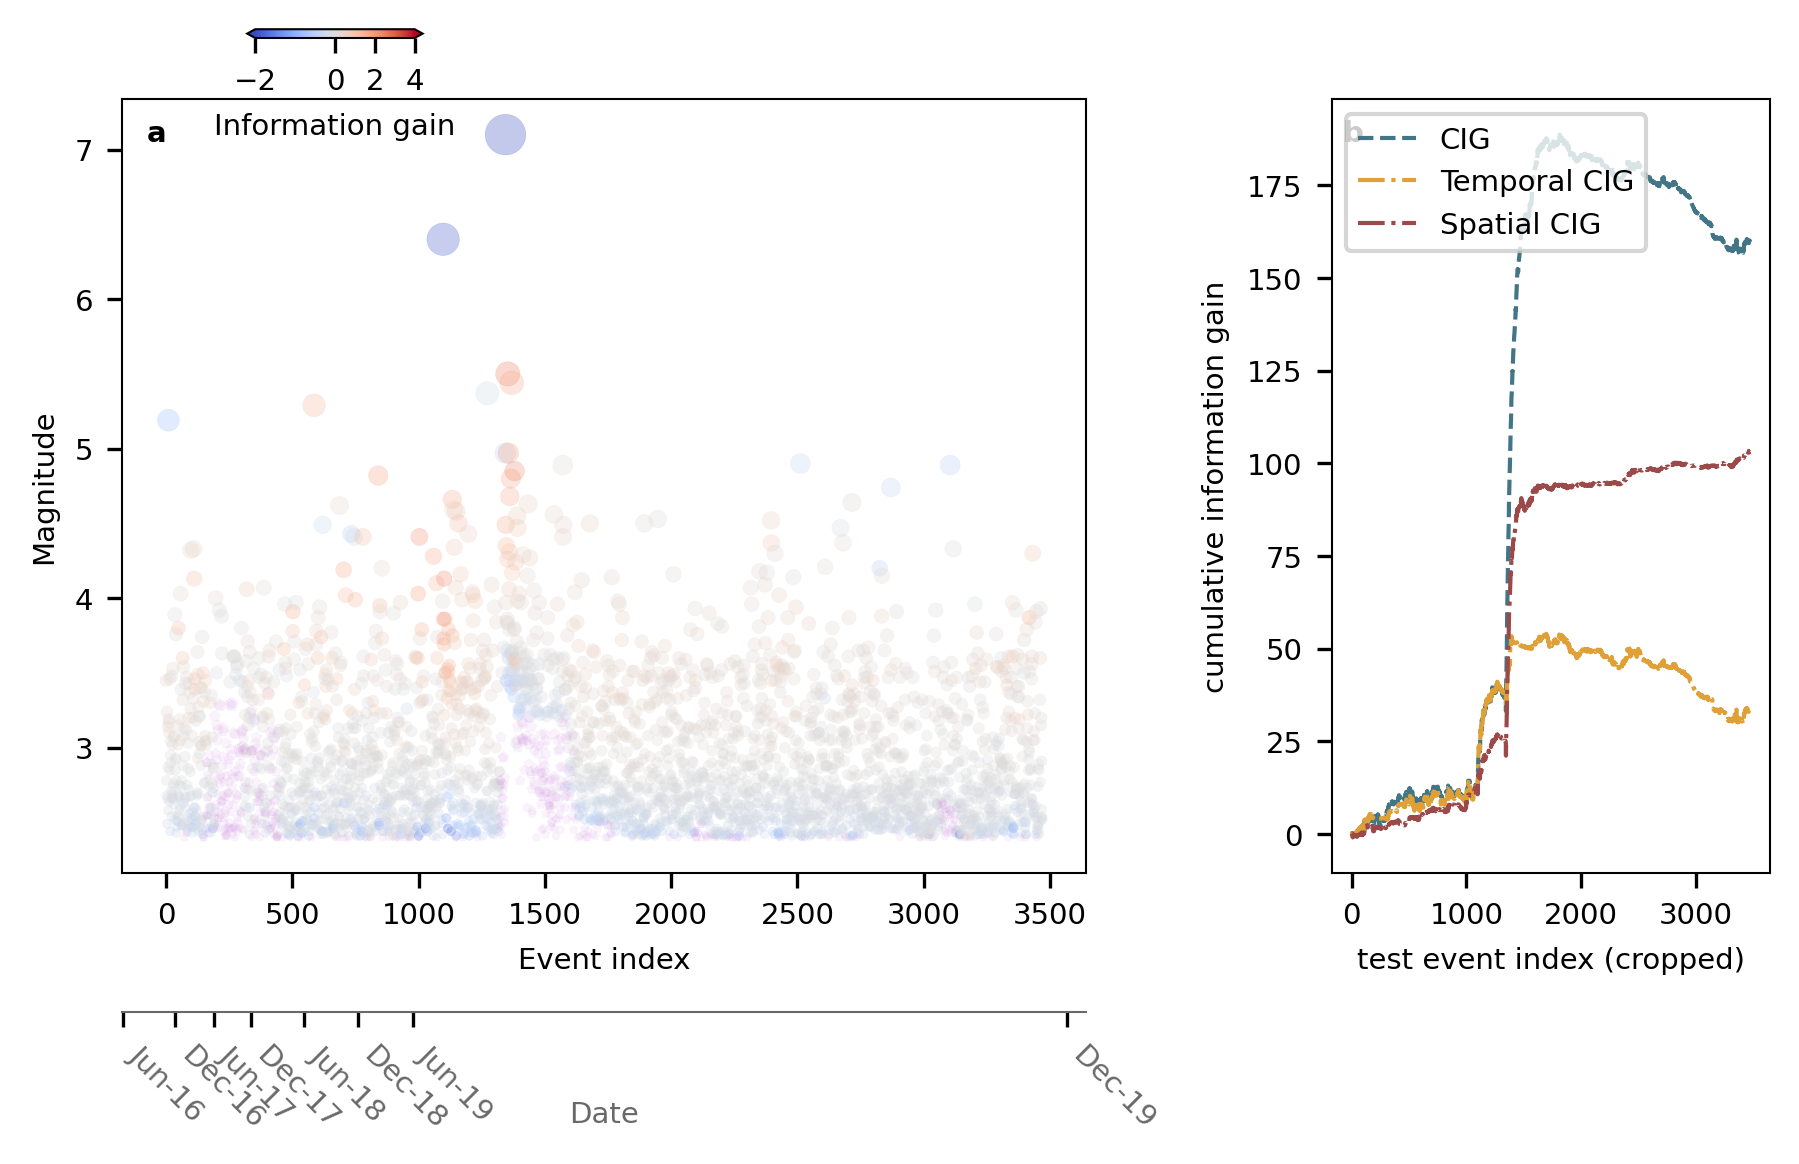

In [27]:
data_set = DATA_NAME
cropped_comparison_catalog = data_name_and_experiments_dict[data_set]['cropped_comparison_catalog']

main_fig = plt.figure(figsize=(SCALE * 180 / INCHES_TO_MM, SCALE * 85 / INCHES_TO_MM))
gs = GridSpec(1, 2, width_ratios=[2.2, 1], wspace=0.35)
ax_scatter = main_fig.add_subplot(gs[0, 0])
ax_cig = main_fig.add_subplot(gs[0, 1])

scatter_color = 'log_difference_conditioned'
sc = add_scatter_to_axes(ax_scatter, cropped_comparison_catalog, scatter_color=scatter_color)
plot_letter(ax_scatter, 'a')

x_info_gain = np.arange(len(cropped_comparison_catalog))
ax_cig.plot(x_info_gain, cropped_comparison_catalog['information_gain'].values, '--', color=INFO_GAIN_COLOR, label='CIG')
ax_cig.plot(
    x_info_gain,
    cropped_comparison_catalog['information_gain_conditioned'].values,
    '-.',
    color=INFO_GAIN_COND,
    label='Temporal CIG',
)
ax_cig.plot(
    x_info_gain,
    cropped_comparison_catalog['information_gain_spatial_conditioned'].values,
    '-.',
    color=INFO_GAIN_SPATIAL_CONDITIONED,
    label='Spatial CIG',
)
ax_cig.set_xlabel('test event index (cropped)')
ax_cig.set_ylabel('cumulative information gain')
ax_cig.legend(loc='upper left', fontsize=SMALL_SIZE)
plot_letter(ax_cig, 'b')

axins = main_fig.add_axes([-0.05, 0.92, 0.55, 0.06], visible=False)
axins.axis('off')
main_fig.colorbar(
    ScalarMappable(cmap=sc.get_cmap(), norm=sc.norm),
    ax=axins,
    extend='both',
    label='Information gain',
    location='bottom',
    orientation='horizontal',
    fraction=0.5,
    shrink=0.15,
    aspect=20,
    ticks=[-2, 0, 2, 4],
)

display(main_fig)
if DO_SAVE:
    save_figure(main_fig, 'cum_info_gain_conditioned_scatter')


## Figure 5 — `information_gain_violin_and_func_of_seismicity_2`

/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


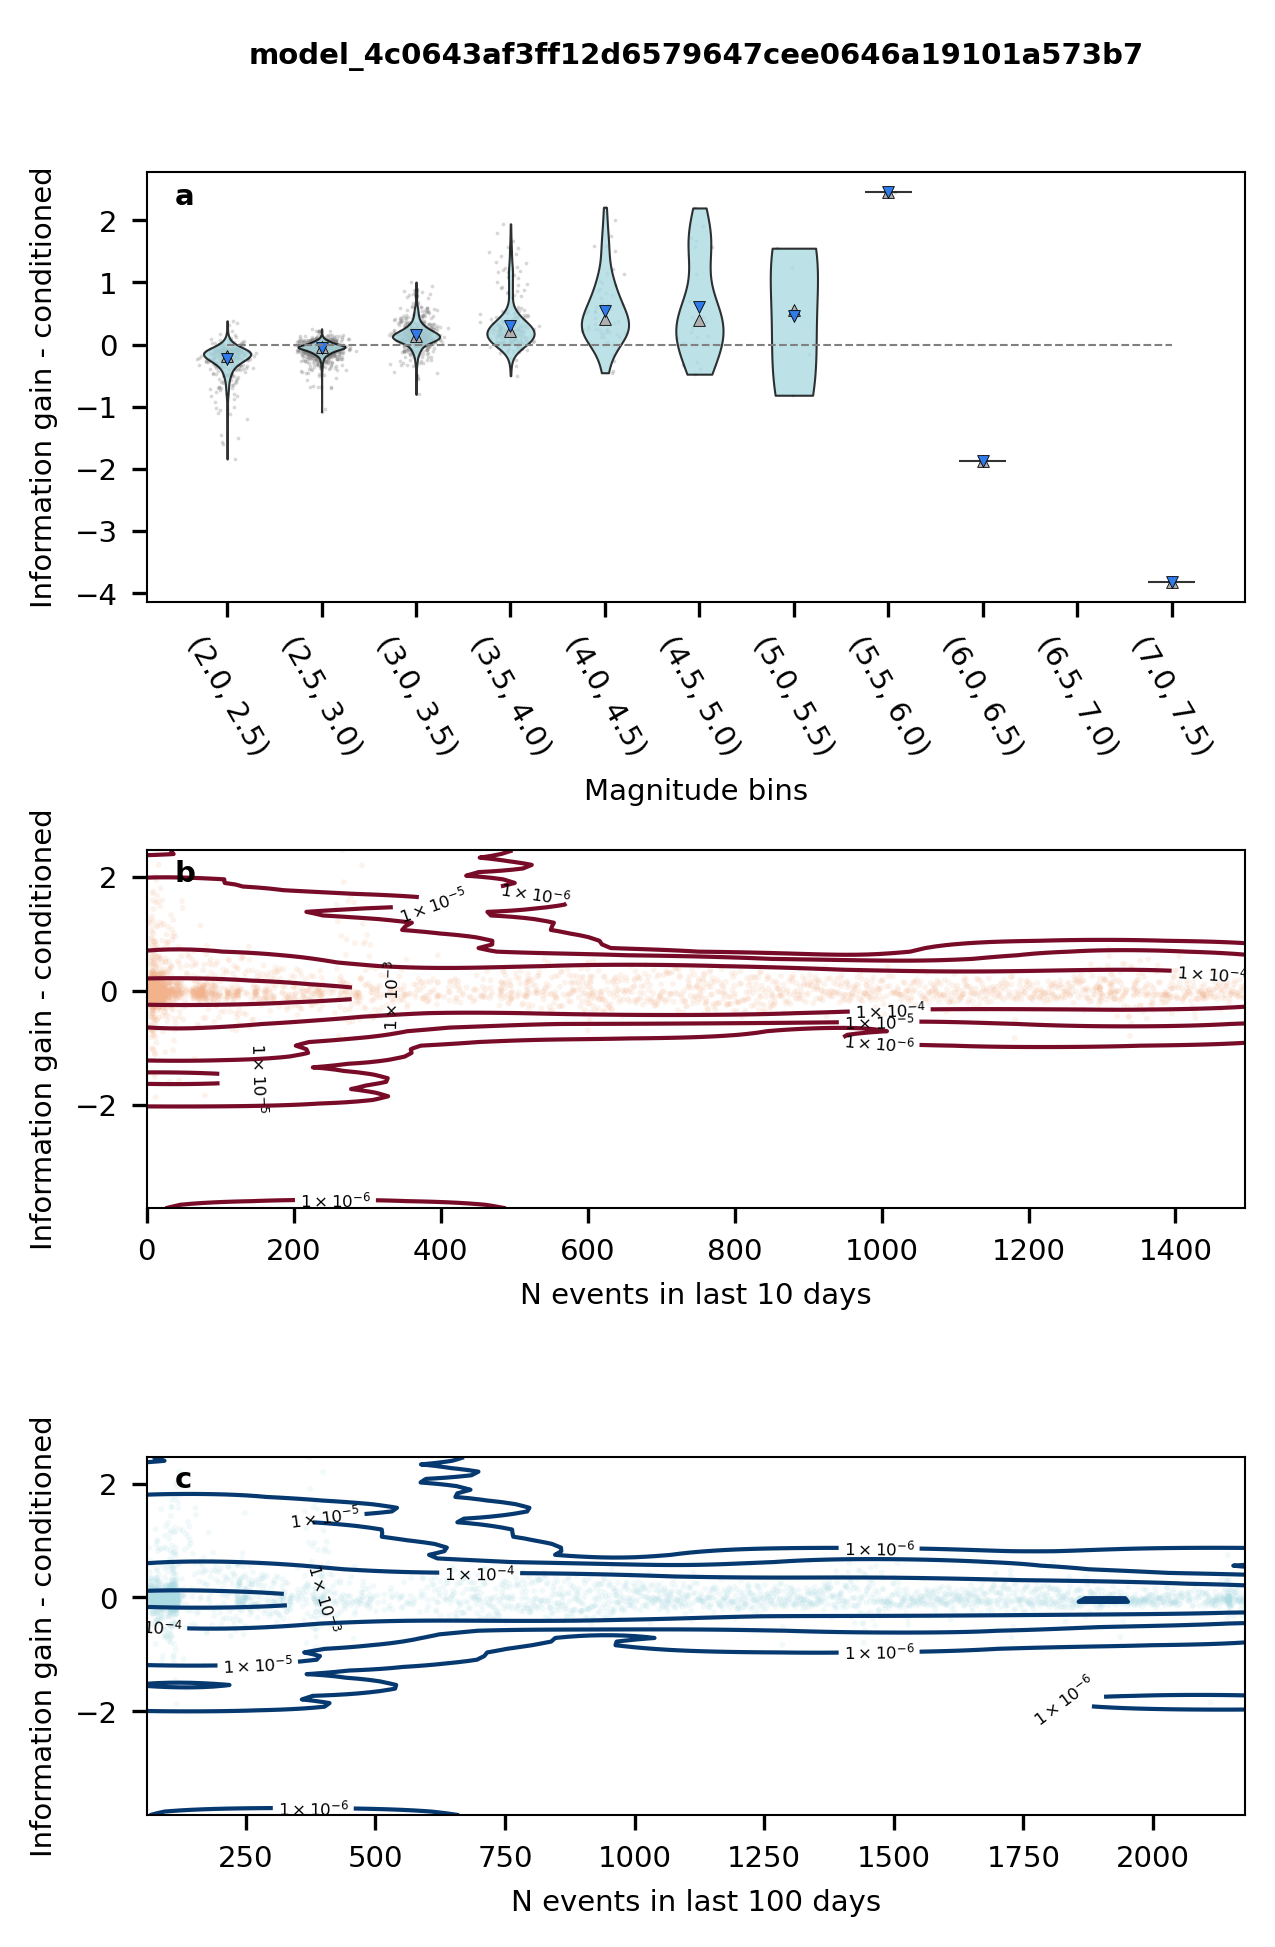

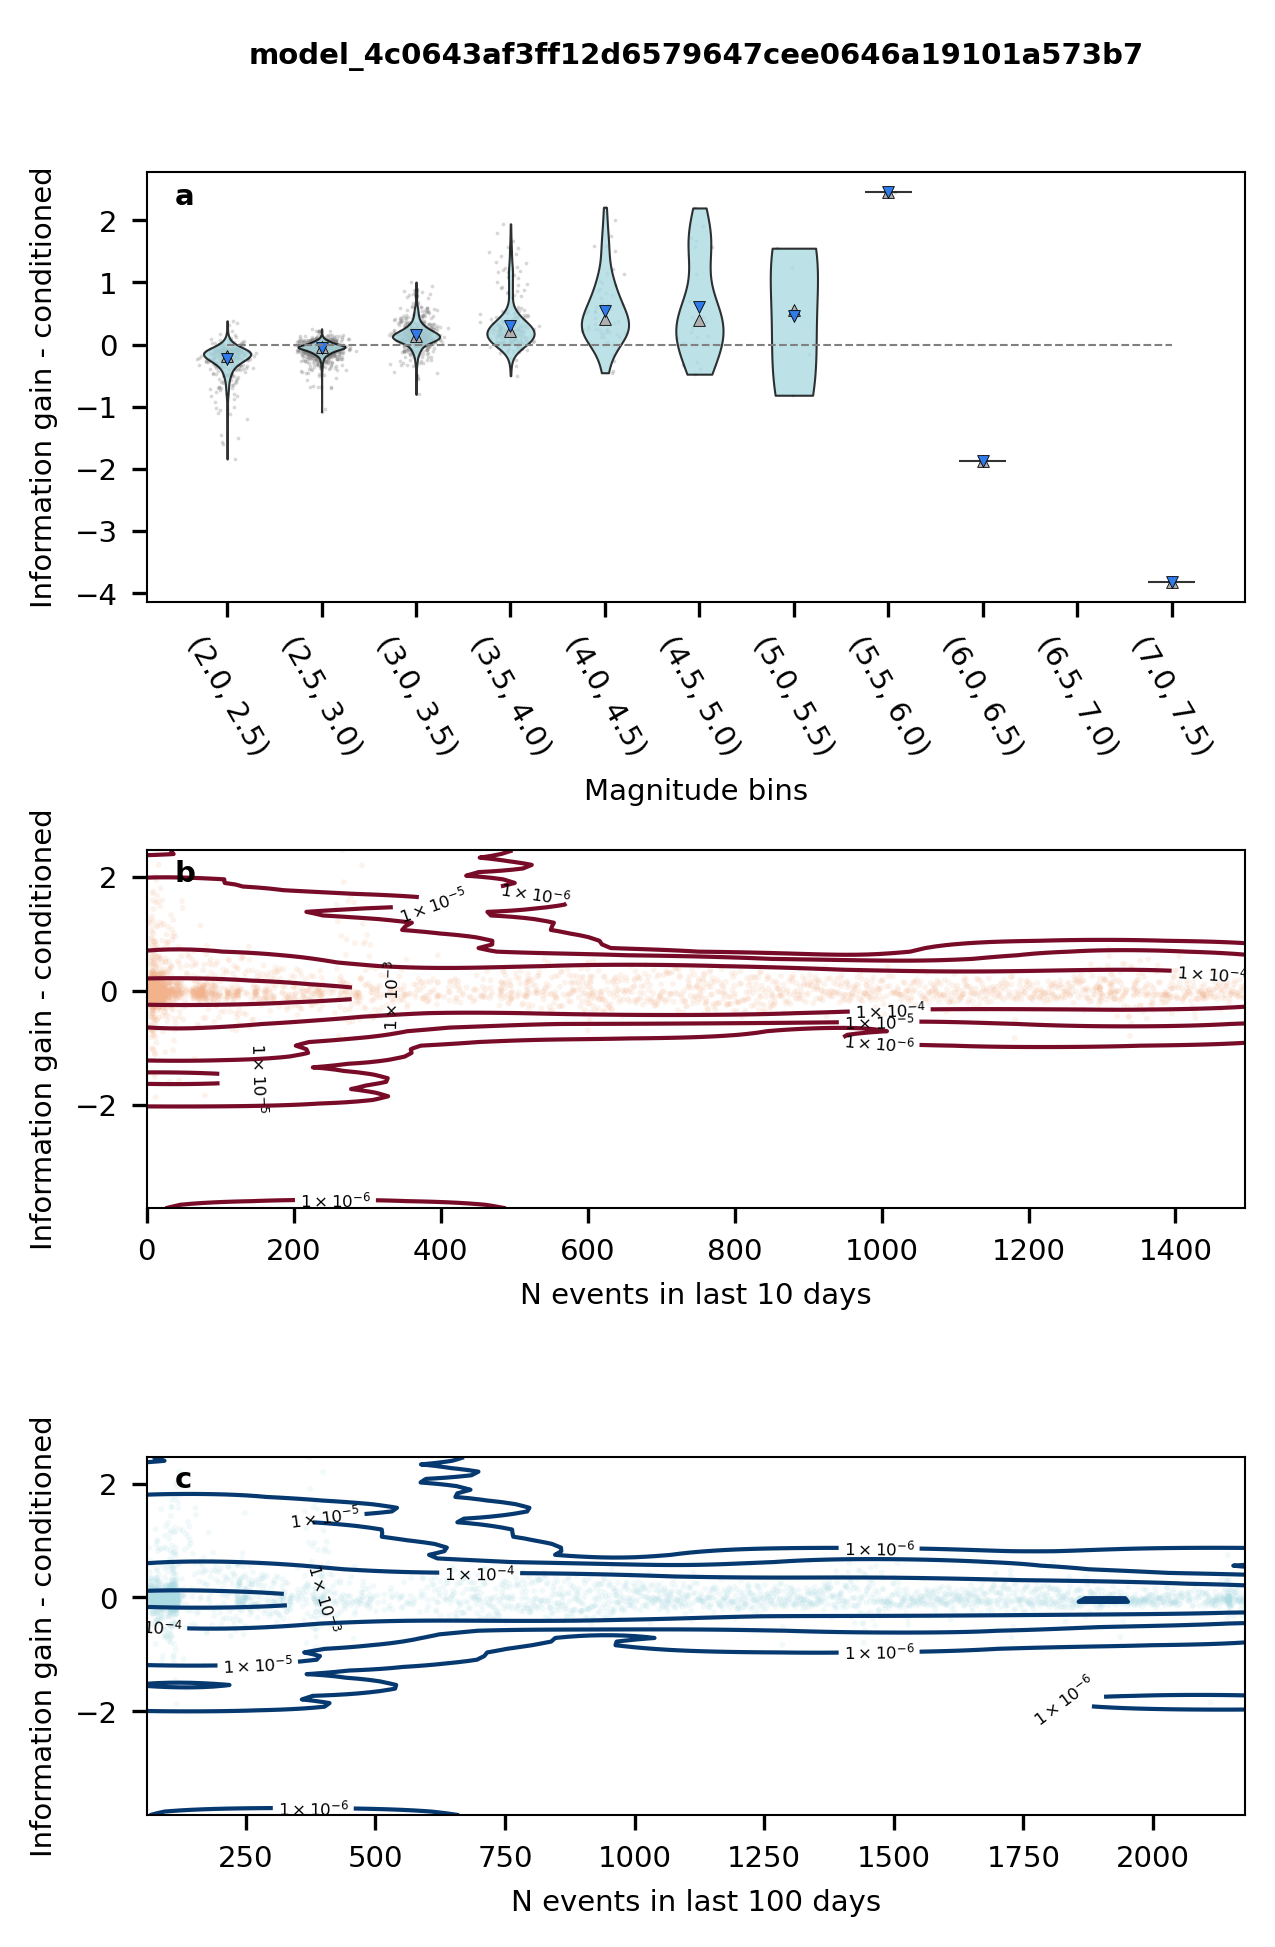

In [ ]:
CONDITIONED_BEST_STR = f'train_gr_likelihood_conditioned_{PRIMARY_MC}'
CONDITIONED_MODEL_STR = f'model_{DATA_NAME}_likelihood_conditioned_{PRIMARY_MC}'
cropped_comparison_catalog = data_name_and_experiments_dict[DATA_NAME]['cropped_comparison_catalog']
labels_local = data_name_and_experiments_dict[DATA_NAME]['labels']
mag_thresh = data_name_and_experiments_dict[DATA_NAME]['MAG_THRESH']

bin_info_fig = plt.figure(figsize=(SCALE * 120 / INCHES_TO_MM, SCALE * 210 / INCHES_TO_MM))
gs = GridSpec(7, 1, height_ratios=[0.15, 1.2, 0.2, 1, 0.2, 1, 0.1], hspace=0.45)
ax_title = bin_info_fig.add_subplot(gs[0, 0])
ax_title.text(0.5, 0.5, DATA_NAME, ha='center', va='center', weight='bold')
ax_title.axis('off')
ax_violin = bin_info_fig.add_subplot(gs[1, 0])
ax_seis_10 = bin_info_fig.add_subplot(gs[3, 0])
ax_seis_100 = bin_info_fig.add_subplot(gs[5, 0])

violin_plot_bin_edges = np.arange(np.floor(mag_thresh), np.ceil(labels_local.test_labels.max()), 0.5)
info_gain = np.log(cropped_comparison_catalog[CONDITIONED_MODEL_STR].values) - np.log(
    cropped_comparison_catalog[CONDITIONED_BEST_STR].values
)
idxs = np.digitize(labels_local.test_labels, violin_plot_bin_edges)
stacked_info_gains = {}
for i, _ in enumerate(violin_plot_bin_edges):
    if i == 0:
        continue
    bin_name = f'({violin_plot_bin_edges[i-1]:.1f}, {violin_plot_bin_edges[i]:.1f})'
    if np.any(idxs == i):
        info_gain_i = info_gain[idxs == i]
        info_gain_i = info_gain_i[np.isfinite(info_gain_i)]
        stacked_info_gains[bin_name] = info_gain_i
    else:
        stacked_info_gains[bin_name] = np.array([np.nan, np.nan])

ax_violin.plot(np.arange(1, len(stacked_info_gains) + 1), [0] * len(stacked_info_gains), '--', color='grey', linewidth=0.5)
random_factor = 0.2
for i, (_, v) in enumerate(stacked_info_gains.items()):
    x = np.random.normal(i + 1, random_factor / 2, size=len(v))
    ax_violin.scatter(x, v, alpha=0.3, color='gray', s=0.8, linewidths=0)
parts = ax_violin.violinplot(stacked_info_gains.values(), showmeans=False, showmedians=False, showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor('#abdbe3')
    pc.set_edgecolor('black')
    pc.set_linewidth(0.5)
    pc.set_alpha(0.8)
medians = [np.median(v) for v in stacked_info_gains.values()]
means = [np.mean(v) for v in stacked_info_gains.values()]
inds = np.arange(1, len(medians) + 1)
ax_violin.scatter(inds, medians, marker='^', color='#afafaf', s=8, edgecolors='k', linewidths=0.2)
ax_violin.scatter(inds, means, marker='v', color='#307ae9', s=8, edgecolors='k', linewidths=0.2)
ax_violin.set_xticks(ticks=np.arange(1, len(stacked_info_gains) + 1), labels=stacked_info_gains.keys(), rotation=-60)
ax_violin.set_xlabel('Magnitude bins')
ax_violin.set_ylabel('Information gain - conditioned')
plot_letter(ax_violin, 'a')

past_seis = past_seismicity_test
contour_colors = ['#780C28', '#063970']
scatter_colors = ['#F2B28C', '#abdbe3']

def fmt_10_neg_x(val):
    if np.isinf(np.log10(val)):
        return r"0"
    exponent = int(np.floor(np.log10(val)))
    base = val / 10**exponent
    return r"${:.0f} \times 10^{{{}}}$".format(base, exponent)

for ax, n_days in zip((ax_seis_10, ax_seis_100), ('10', '100')):
    seismicity = cropped_comparison_catalog[f'past_seismicity_{n_days}_days'].values
    ig_plot = info_gain
    no_nan_logical = np.isfinite(ig_plot) & np.isfinite(seismicity)
    kde = gaussian_kde([ig_plot[no_nan_logical], seismicity[no_nan_logical]])
    x = np.linspace(ig_plot[no_nan_logical].min(), ig_plot[no_nan_logical].max(), 100)
    y = np.linspace(seismicity[no_nan_logical].min(), seismicity[no_nan_logical].max(), 100)
    Xi, Yi = np.meshgrid(x, y)
    Zi = kde([Xi.ravel(), Yi.ravel()]).reshape(Xi.shape)
    counter = 0 if n_days == '10' else 1
    cont = ax.contour(Yi, Xi, Zi, levels=50, colors=[contour_colors[counter]], locator=AsinhLocator(1e-5, numticks=50))
    ax.clabel(cont, fmt=fmt_10_neg_x, colors='k', fontsize=4)
    logical = np.isfinite(seismicity) & np.isfinite(ig_plot)
    correlation = np.corrcoef(ig_plot[logical], seismicity[logical])[0, 1]
    ax.scatter(
        seismicity,
        ig_plot,
        s=2,
        alpha=0.15,
        label=f'Past {n_days} days (r={correlation:.2f})',
        facecolor=scatter_colors[counter],
        edgecolor='none',
    )
    ax.set_xlabel(f'N events in last {n_days} days')
    ax.set_ylabel('Information gain - conditioned')

plot_letter(ax_seis_10, 'b')
plot_letter(ax_seis_100, 'c')

display(bin_info_fig)
if DO_SAVE:
    save_figure(bin_info_fig, 'information_gain_violin_and_func_of_seismicity_2')
